# TinyBench — Evaluation Results Analysis

In [24]:
import json, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ── Constants ─────────────────────────────────────────────────────────────
GRADE_COLORS = {
    "CORRECT":   "#2ecc71",
    "PARTIAL":   "#f39c12",
    "INCORRECT": "#e74c3c",
}

PROVIDER_COLORS = {
    "Anthropic": "#3b82f6",
    "OpenAI":    "#22c55e",
    "Ollama":    "#f97316",
}

TEMPLATE_CATEGORY = {
    "anomaly_riskier_group_v0":       "surprise_anomaly",
    "anomaly_data_quality_filter_v0": "surprise_anomaly",
    "anomaly_data_quality_filter_v1": "surprise_anomaly",
    "fi_leakage_topk_v0":             "feature_importance",
    "rca_performance_improve_v0":     "root_cause",
    "rca_retrain_point_v0":           "root_cause",
}

RUN_ORDER = ["blind", "csv_context", "semantic_only", "python_only", "all_tools",
             "raw", "semantic", "tools"]
RUN_COLORS = {
    "blind":         "#6366f1",
    "csv_context":   "#f59e0b",
    "semantic_only": "#22c55e",
    "python_only":   "#3b82f6",
    "all_tools":     "#ef4444",
    "raw":           "#a855f7",
    "semantic":      "#14b8a6",
    "tools":         "#f97316",
}
RUN_LABELS = {r: r.replace("_", " ").title() for r in RUN_ORDER}

# ── Helper functions ──────────────────────────────────────────────────────
def infer_run(filename: str) -> str:
    """Infer run type from filename or its parent directory path."""
    full_path = Path(filename)
    # Check both the filename stem and the full path string
    candidates = [full_path.stem.lower(), str(full_path).lower()]
    for text in candidates:
        if "blind" in text:           return "blind"
        if "all_tools" in text:       return "all_tools"
        if "csv_context" in text:     return "csv_context"
        if "semantic_only" in text:   return "semantic_only"
        if "python_semantic" in text: return "semantic"
        if "python_only" in text:     return "python_only"
        if "semantic" in text:        return "semantic"
        if "tools" in text:           return "tools"
        if "raw" in text:             return "raw"
    return full_path.stem

def infer_provider(model: str) -> str:
    if model.startswith("claude"):                    return "Anthropic"
    if model.startswith(("gpt-", "o1", "o3", "o4")): return "OpenAI"
    return "Ollama"

def _parse_size(ds: str) -> int:
    """Extract numeric row count from dataset name like 'bike_sharing_100'."""
    m = re.search(r"_(\d+)$", ds)
    return int(m.group(1)) if m else 0

# ── Configuration ─────────────────────────────────────────────────────────
RESULT_FILES = [
]

GRADED_RESULTS_DIR = Path("../data/results/graded/")

# ── Load ──────────────────────────────────────────────────────────────────
if RESULT_FILES:
    paths = [Path(p) for p in RESULT_FILES]
else:
    paths = sorted(GRADED_RESULTS_DIR.glob("eval_*graded*.json"))

if not paths:
    raise FileNotFoundError(
        f"No eval_*graded*.json files found in {GRADED_RESULTS_DIR.resolve()}. "
        "Set RESULT_FILES or GRADED_RESULTS_DIR to point to your graded results."
    )

print(f"Loaded {len(paths)} result file(s):")
for p in paths:
    print(f"  {p}  →  run='{infer_run(str(p))}'")

records = []
for path in paths:
    run = infer_run(str(path))
    with open(path) as f:
        data = json.load(f)
    for entry in data:
        entry["run"] = run
        records.append(entry)

df = pd.DataFrame(records)

# ── Derived columns ───────────────────────────────────────────────────────
df["provider"] = df["model"].apply(infer_provider)
df["category"] = df["template_id"].map(TEMPLATE_CATEGORY).fillna("other")

# Dataset size (numeric + string)
df["dataset_size"] = df["dataset"].apply(_parse_size)
df["size"] = df["dataset_size"].astype(str)

# Unpack metrics dict
if "metrics" in df.columns:
    metrics_df = pd.json_normalize(df["metrics"])
    for col in metrics_df.columns:
        df[col] = metrics_df[col].values

if "input_tokens" in df.columns and "output_tokens" in df.columns:
    df["total_tokens"] = df["input_tokens"].fillna(0) + df["output_tokens"].fillna(0)

# Error flags
if "is_empty_answer" not in df.columns:
    # Also check legacy column name from older result files
    if "is_context_error" in df.columns:
        df["is_empty_answer"] = df["is_context_error"]
    else:
        df["is_empty_answer"] = df["model_answer"].apply(
            lambda x: x is None or (isinstance(x, str) and x.strip() == "")
        )
df["is_error"] = df["is_empty_answer"] | df["grade"].isna()

# ── Key DataFrames ────────────────────────────────────────────────────────
df_ok = df[~df["is_empty_answer"]].copy()
present_runs = [r for r in RUN_ORDER if r in df["run"].unique()]

print(f"\n{len(df)} total records  |  {df['model'].nunique()} models  |  "
      f"{df['run'].nunique()} runs  |  {df['template_id'].nunique()} templates")
print(f"Empty answers: {df['is_empty_answer'].sum()}")
print(f"Records after excluding empty answers: {len(df_ok)} / {len(df)}")
print(f"Runs present: {present_runs}")

Loaded 2 result file(s):
  ../data/results/graded/eval_results_claude-opus-4-6_tools_get_semantic_context_run_python_graded.json  →  run='semantic'
  ../data/results/graded/eval_results_claude-opus-4-6_tools_run_python_graded.json  →  run='tools'

132 total records  |  1 models  |  2 runs  |  9 templates
Empty answers: 18
Records after excluding empty answers: 114 / 132
Runs present: ['semantic', 'tools']


---
## 1 — Overall Accuracy by Model

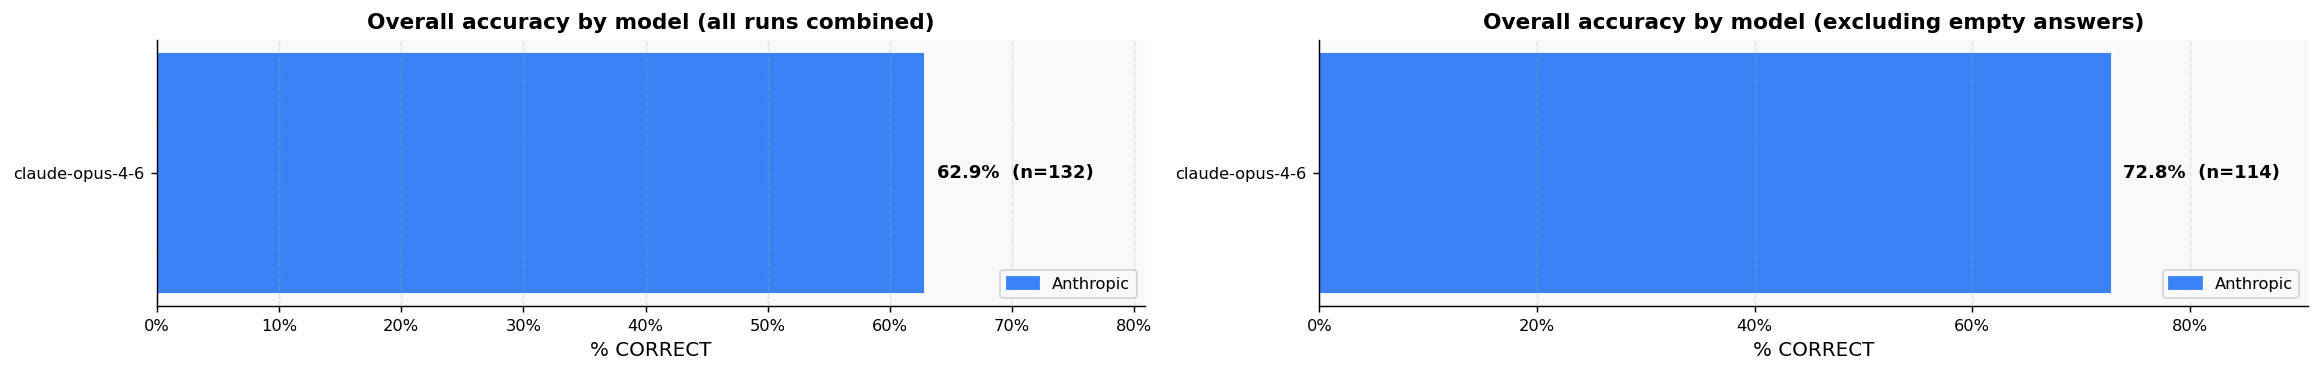

In [25]:
# Side-by-side: all data vs excluding empty answers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(3, df["model"].nunique() * 0.7)))

for ax, source, title_suffix in [
    (ax1, df, "all runs combined"),
    (ax2, df_ok, "excluding empty answers"),
]:
    acc = (
        source.groupby("model")["grade"]
        .apply(lambda g: (g == "CORRECT").mean())
        .sort_values(ascending=True)
    )
    colors = [PROVIDER_COLORS[infer_provider(m)] for m in acc.index]
    bars = ax.barh(acc.index, acc.values, color=colors, height=0.55, edgecolor="white")
    for bar, v, m in zip(bars, acc.values, acc.index):
        n = len(source[source["model"] == m])
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.1%}  (n={n})", va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, min(acc.max() + 0.18, 1.0))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("% CORRECT")
    ax.set_title(f"Overall accuracy by model ({title_suffix})")
    present = sorted(source["provider"].unique())
    ax.legend(handles=[Patch(color=PROVIDER_COLORS[p], label=p) for p in present],
              loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

---
## 2 — Grade Distribution

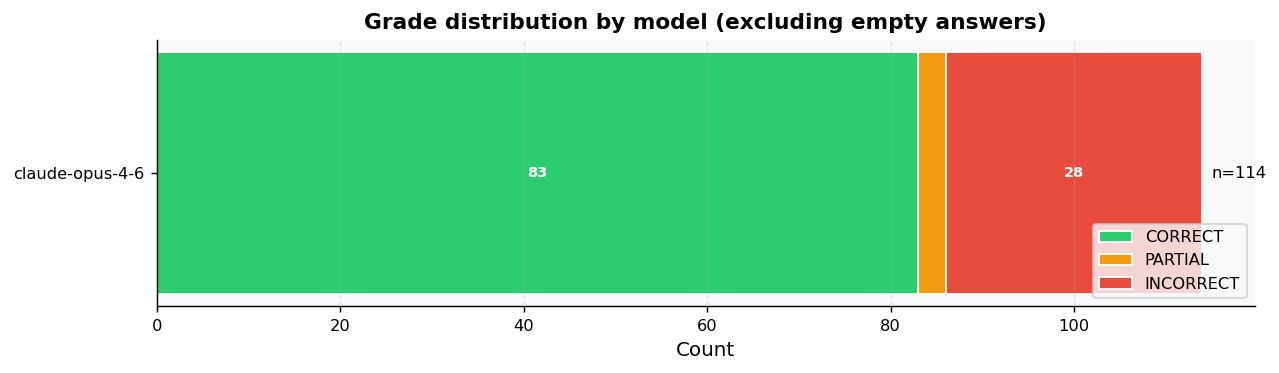

In [26]:
GRADE_ORDER = ["CORRECT", "PARTIAL", "INCORRECT"]
models_ok = sorted(df_ok["model"].unique())

counts_ok = df_ok.groupby(["model", "grade"]).size().unstack(fill_value=0)
for g in GRADE_ORDER:
    if g not in counts_ok.columns:
        counts_ok[g] = 0
counts_ok = counts_ok[GRADE_ORDER].loc[models_ok]

fig, ax = plt.subplots(figsize=(10, max(3, len(models_ok) * 0.7)))

lefts = np.zeros(len(models_ok))
for grade in GRADE_ORDER:
    vals = counts_ok[grade].values
    ax.barh(models_ok, vals, left=lefts, color=GRADE_COLORS[grade],
            label=grade, height=0.55, edgecolor="white")
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > counts_ok.sum(axis=1).iloc[i] * 0.06:
            ax.text(l + v / 2, i, str(v), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    lefts += vals

for i, m in enumerate(models_ok):
    total = counts_ok.loc[m].sum()
    ax.text(total + 1, i, f"n={total}", va="center", fontsize=9)

ax.set_xlabel("Count")
ax.set_title("Grade distribution by model (excluding empty answers)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

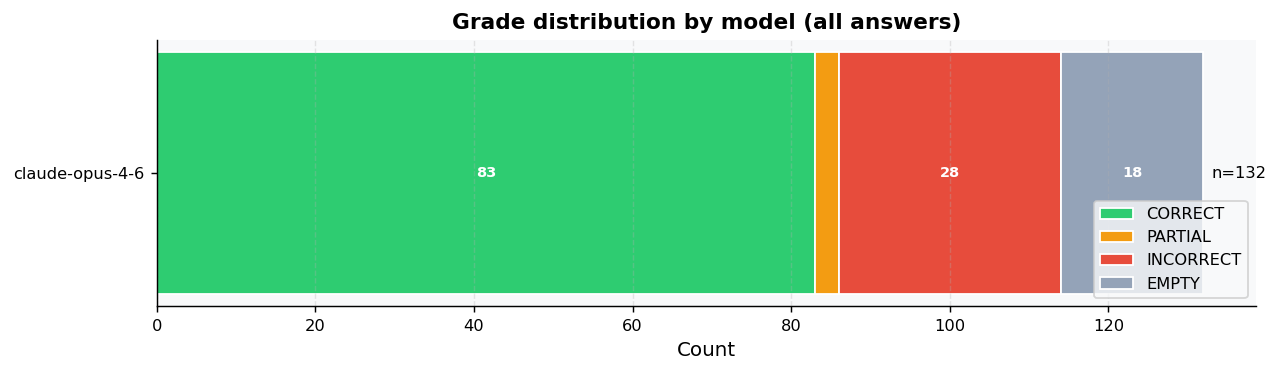

In [27]:
# Grade distribution — ALL answers (empty answers shown as "EMPTY")
GRADE_ORDER_ALL = ["CORRECT", "PARTIAL", "INCORRECT", "EMPTY"]
GRADE_COLORS_ALL = {**GRADE_COLORS, "EMPTY": "#94a3b8"}

df_graded = df.copy()
df_graded["grade_filled"] = df_graded["grade"].fillna("EMPTY")
df_graded.loc[df_graded["is_empty_answer"], "grade_filled"] = "EMPTY"

models_all = sorted(df_graded["model"].unique())
counts_all = df_graded.groupby(["model", "grade_filled"]).size().unstack(fill_value=0)
for g in GRADE_ORDER_ALL:
    if g not in counts_all.columns:
        counts_all[g] = 0
counts_all = counts_all[GRADE_ORDER_ALL].loc[models_all]

fig, ax = plt.subplots(figsize=(10, max(3, len(models_all) * 0.7)))

lefts = np.zeros(len(models_all))
for grade in GRADE_ORDER_ALL:
    vals = counts_all[grade].values
    ax.barh(models_all, vals, left=lefts, color=GRADE_COLORS_ALL[grade],
            label=grade, height=0.55, edgecolor="white")
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > counts_all.sum(axis=1).iloc[i] * 0.06:
            ax.text(l + v / 2, i, str(v), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    lefts += vals

for i, m in enumerate(models_all):
    total = counts_all.loc[m].sum()
    ax.text(total + 1, i, f"n={total}", va="center", fontsize=9)

ax.set_xlabel("Count")
ax.set_title("Grade distribution by model (all answers)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

---
## 3 — Accuracy by Run Condition

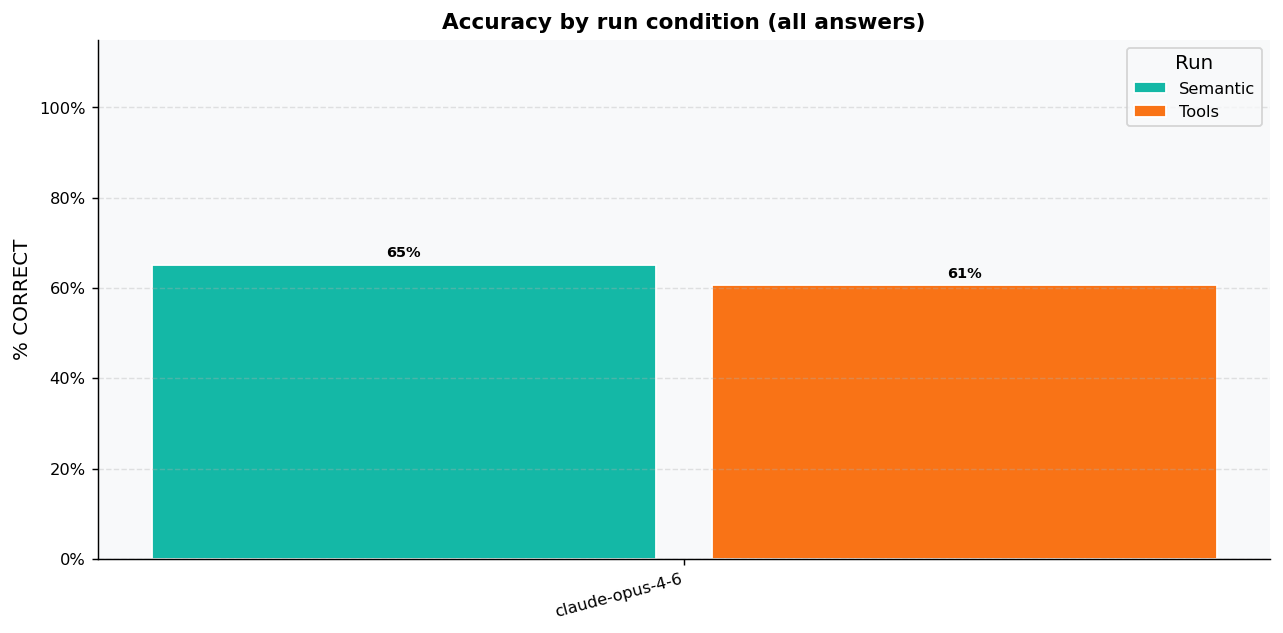

In [28]:
# Accuracy by run condition — ALL answers (empty answers count as not CORRECT)
models_all_list = sorted(df["model"].unique())

fig, ax = plt.subplots(figsize=(max(10, len(models_all_list) * 1.4), 5))

n_models = len(models_all_list)
n_runs = len(present_runs)
bar_w = 0.7 / max(n_runs, 1)
x = np.arange(n_models)

for ri, run in enumerate(present_runs):
    accs = []
    for m in models_all_list:
        sub = df[(df["model"] == m) & (df["run"] == run)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, accs):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models_all_list, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by run condition (all answers)")
ax.legend(fontsize=9, title="Run")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

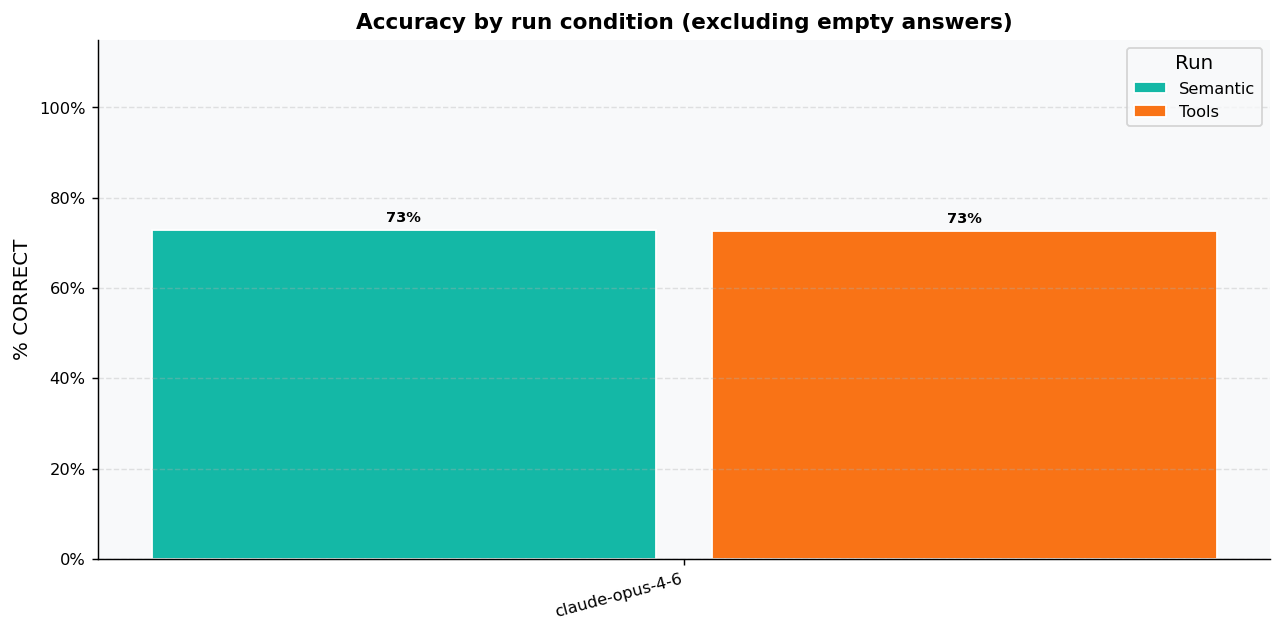

In [29]:
models_ok_list = sorted(df_ok["model"].unique())

fig, ax = plt.subplots(figsize=(max(10, len(models_ok_list) * 1.4), 5))

n_models = len(models_ok_list)
n_runs = len(present_runs)
bar_w = 0.7 / max(n_runs, 1)
x = np.arange(n_models)

for ri, run in enumerate(present_runs):
    accs = []
    for m in models_ok_list:
        sub = df_ok[(df_ok["model"] == m) & (df_ok["run"] == run)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, accs):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models_ok_list, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by run condition (excluding empty answers)")
ax.legend(fontsize=9, title="Run")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

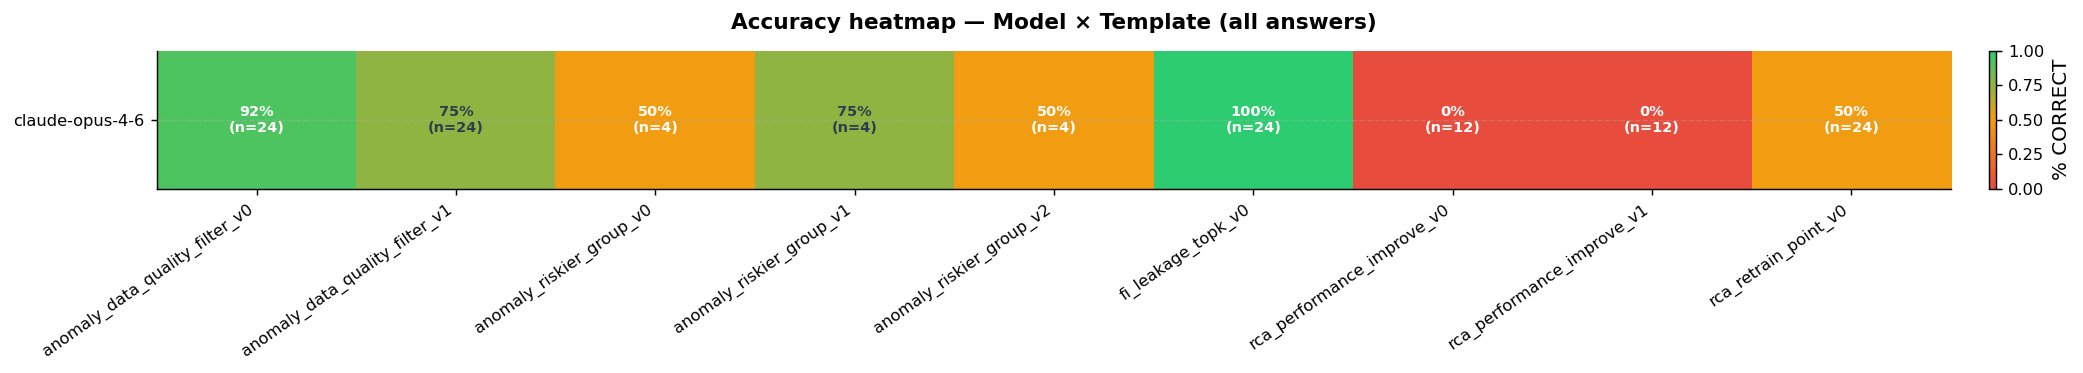

In [30]:
# Accuracy heatmap: Model x Template — ALL answers (empty answers count as not CORRECT)
cmap = LinearSegmentedColormap.from_list("rg", ["#e74c3c", "#f39c12", "#2ecc71"], N=256)
models_hm_all = sorted(df["model"].unique())
templates_hm_all = sorted(df["template_id"].unique())

matrix_all = np.full((len(models_hm_all), len(templates_hm_all)), np.nan)
counts_hm_all = np.zeros_like(matrix_all, dtype=int)

for i, m in enumerate(models_hm_all):
    for j, t in enumerate(templates_hm_all):
        sub = df[(df["model"] == m) & (df["template_id"] == t)]
        if len(sub):
            matrix_all[i, j] = (sub["grade"] == "CORRECT").mean()
            counts_hm_all[i, j] = len(sub)

fig, ax = plt.subplots(
    figsize=(max(8, len(templates_hm_all) * 1.8), max(3, len(models_hm_all) * 0.9 + 1))
)
im = ax.imshow(matrix_all, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(templates_hm_all)))
ax.set_xticklabels(templates_hm_all, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(models_hm_all)))
ax.set_yticklabels(models_hm_all, fontsize=9)

for i in range(len(models_hm_all)):
    for j in range(len(templates_hm_all)):
        v = matrix_all[i, j]
        n = counts_hm_all[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\n(n={n})", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if v < 0.55 or v > 0.75 else "#2c3e50")

plt.colorbar(im, ax=ax, label="% CORRECT", fraction=0.03, pad=0.02)
ax.set_title("Accuracy heatmap — Model × Template (all answers)", pad=12)
plt.tight_layout()
plt.show()

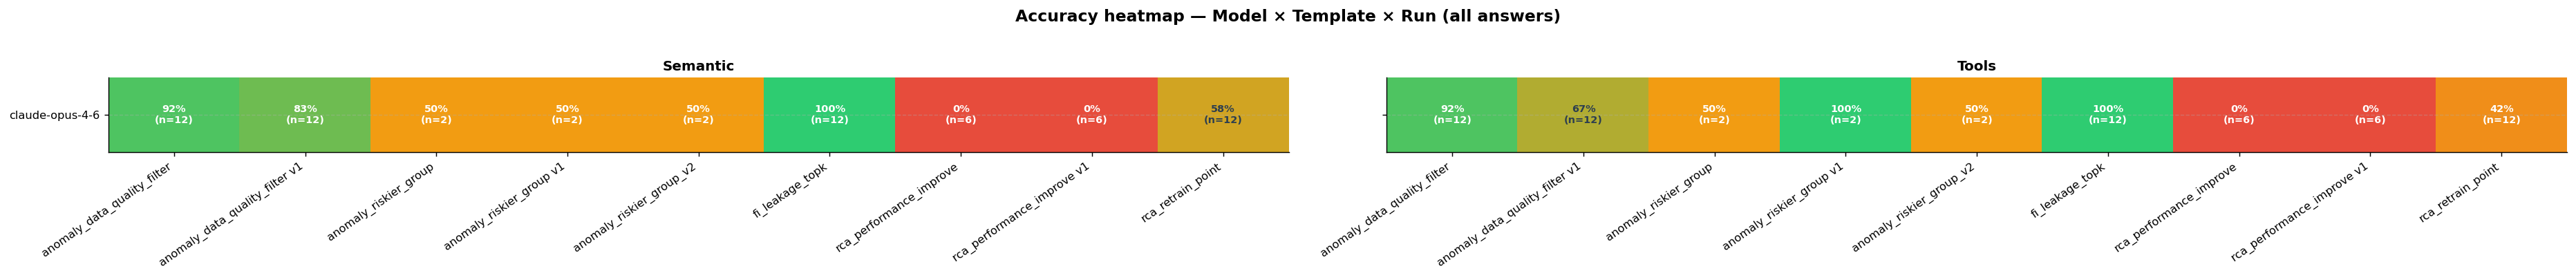

In [31]:
# Accuracy heatmap: Model × Template × Run — side-by-side comparison (all answers)
models_comp = sorted(df["model"].unique())
templates_comp = sorted(df["template_id"].unique())
short_templates = [t.replace("_v0", "").replace("_v1", " v1") for t in templates_comp]

n_runs_comp = len(present_runs)
fig, axes = plt.subplots(
    1, n_runs_comp,
    figsize=(max(7, len(templates_comp) * 1.6) * n_runs_comp, max(3, len(models_comp) * 0.9 + 1)),
    sharey=True,
)
if n_runs_comp == 1:
    axes = [axes]

for ax, run in zip(axes, present_runs):
    matrix_r = np.full((len(models_comp), len(templates_comp)), np.nan)
    counts_r = np.zeros_like(matrix_r, dtype=int)

    for i, m in enumerate(models_comp):
        for j, t in enumerate(templates_comp):
            sub = df[(df["model"] == m) & (df["template_id"] == t) & (df["run"] == run)]
            if len(sub):
                matrix_r[i, j] = (sub["grade"] == "CORRECT").mean()
                counts_r[i, j] = len(sub)

    im = ax.imshow(matrix_r, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    ax.set_xticks(range(len(templates_comp)))
    ax.set_xticklabels(short_templates, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(len(models_comp)))
    ax.set_yticklabels(models_comp, fontsize=9)

    for i in range(len(models_comp)):
        for j in range(len(templates_comp)):
            v = matrix_r[i, j]
            n = counts_r[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0%}\n(n={n})", ha="center", va="center",
                        fontsize=8, fontweight="bold",
                        color="white" if v < 0.55 or v > 0.75 else "#2c3e50")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="#94a3b8")

    run_label = RUN_LABELS.get(run, run)
    ax.set_title(f"{run_label}", fontsize=11)

# fig.colorbar(im, ax=axes, label="% CORRECT", fraction=0.02, pad=0.02)
fig.suptitle("Accuracy heatmap — Model × Template × Run (all answers)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4 — Accuracy Heatmap: Model × Template

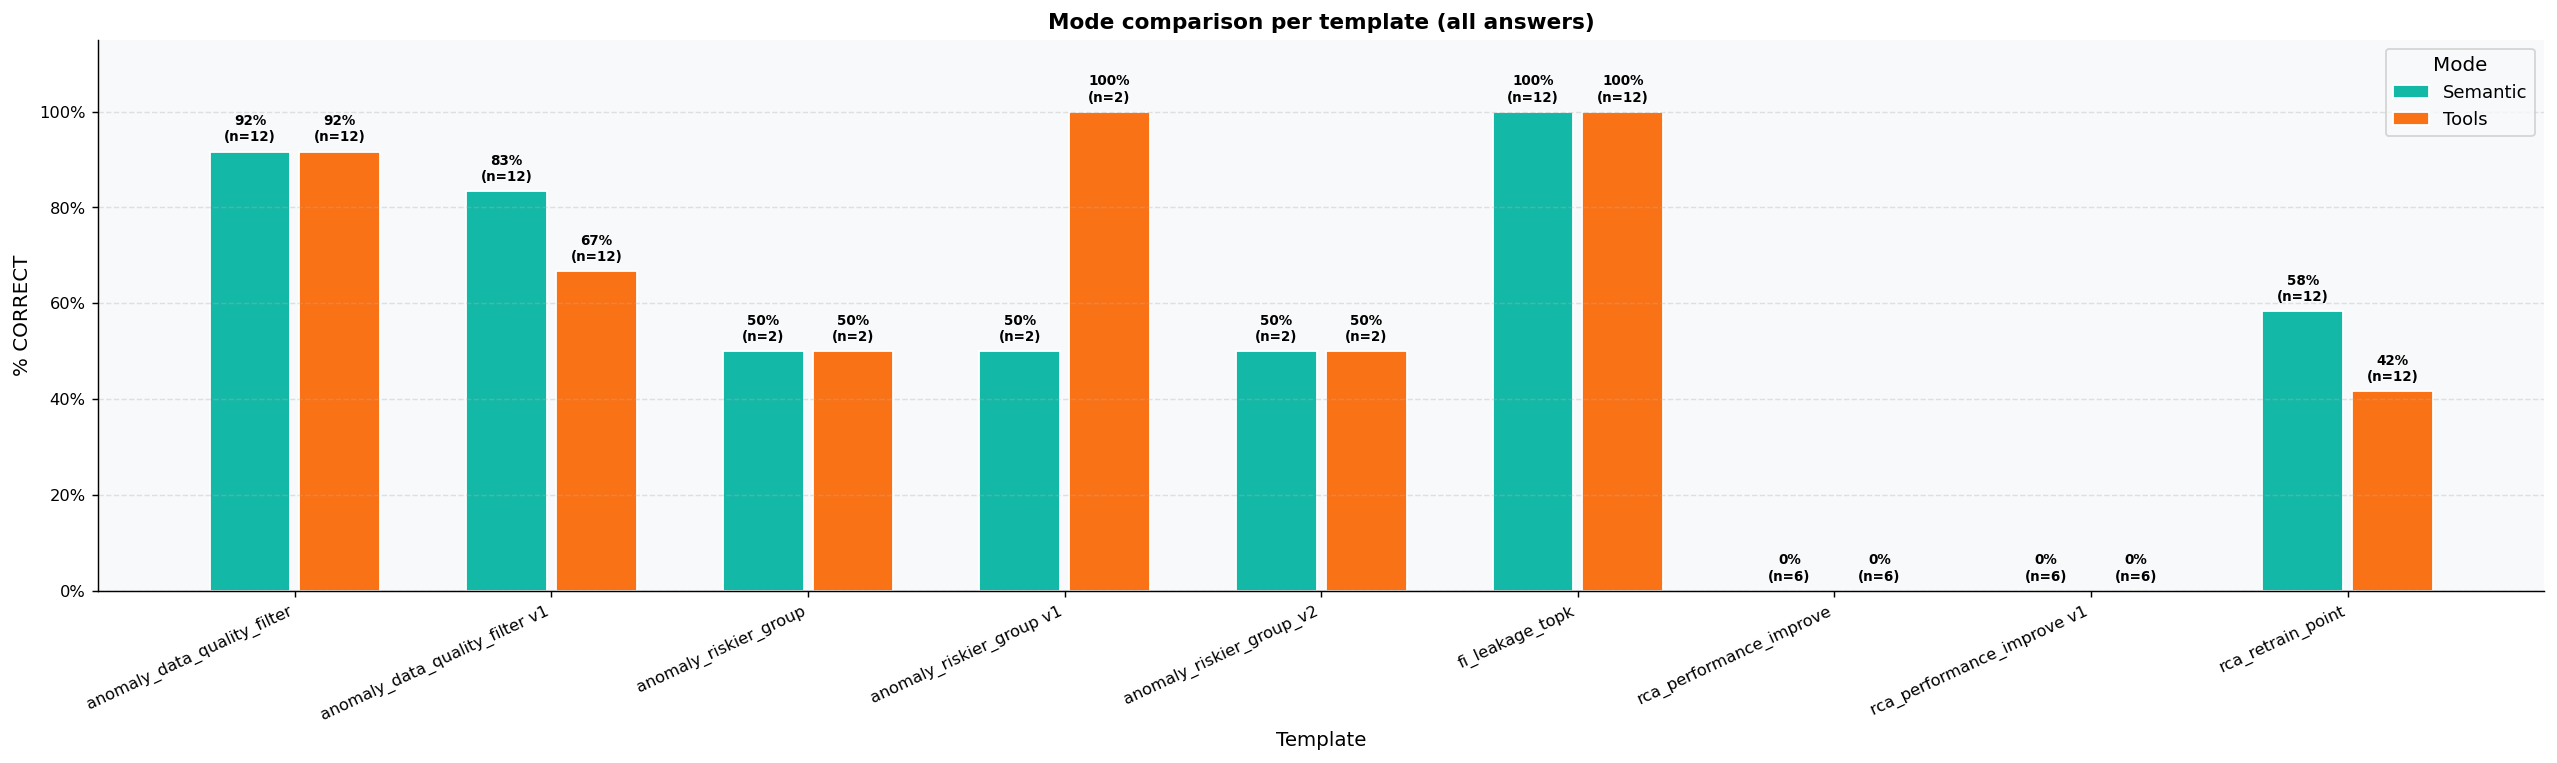

In [32]:
# Accuracy by mode per template — grouped bar chart (all answers)
templates_mode = sorted(df["template_id"].unique())
short_labels_mode = [t.replace("_v0", "").replace("_v1", " v1") for t in templates_mode]

fig, ax = plt.subplots(figsize=(max(10, len(templates_mode) * 2.2), 6))

n_templates = len(templates_mode)
n_runs = len(present_runs)
bar_w = 0.7 / max(n_runs, 1)
x = np.arange(n_templates)

for ri, run in enumerate(present_runs):
    accs, ns = [], []
    for t in templates_mode:
        sub = df[(df["template_id"] == t) & (df["run"] == run)]
        if len(sub):
            accs.append((sub["grade"] == "CORRECT").mean())
            ns.append(len(sub))
        else:
            accs.append(np.nan)
            ns.append(0)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
    for bar, v, n in zip(bars, accs, ns):
        if n > 0 and not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                    f"{v:.0%}\n(n={n})", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(short_labels_mode, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_xlabel("Template")
ax.set_title("Mode comparison per template (all answers)")
ax.legend(fontsize=10, title="Mode")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

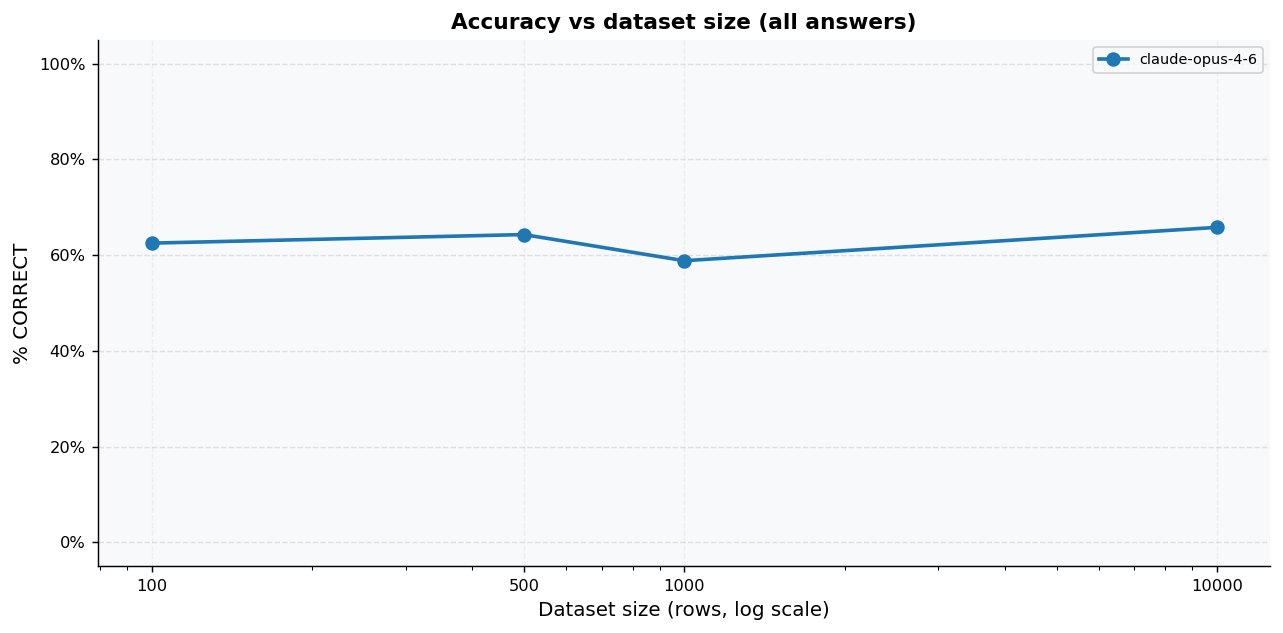

In [33]:
# Accuracy by dataset size — ALL answers (empty answers count as not CORRECT)
sizes_all = sorted(df["dataset_size"].dropna().unique().astype(int))
models_sz_all = sorted(df["model"].unique())
MODEL_COLORS_ALL = plt.cm.tab10(np.linspace(0, 0.7, len(models_sz_all)))

if len(sizes_all) < 2:
    print("Only one dataset size — skipping.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for mi, m in enumerate(models_sz_all):
        accs = []
        for s in sizes_all:
            sub = df[(df["model"] == m) & (df["dataset_size"] == s)]
            accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
        ax.plot(sizes_all, accs, "o-", color=MODEL_COLORS_ALL[mi], label=m, linewidth=2, markersize=7)

    ax.set_xscale("log")
    ax.set_xticks(sizes_all)
    ax.set_xticklabels([str(s) for s in sizes_all])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Dataset size (rows, log scale)")
    ax.set_ylabel("% CORRECT")
    ax.set_title("Accuracy vs dataset size (all answers)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.15)
    plt.tight_layout()
    plt.show()

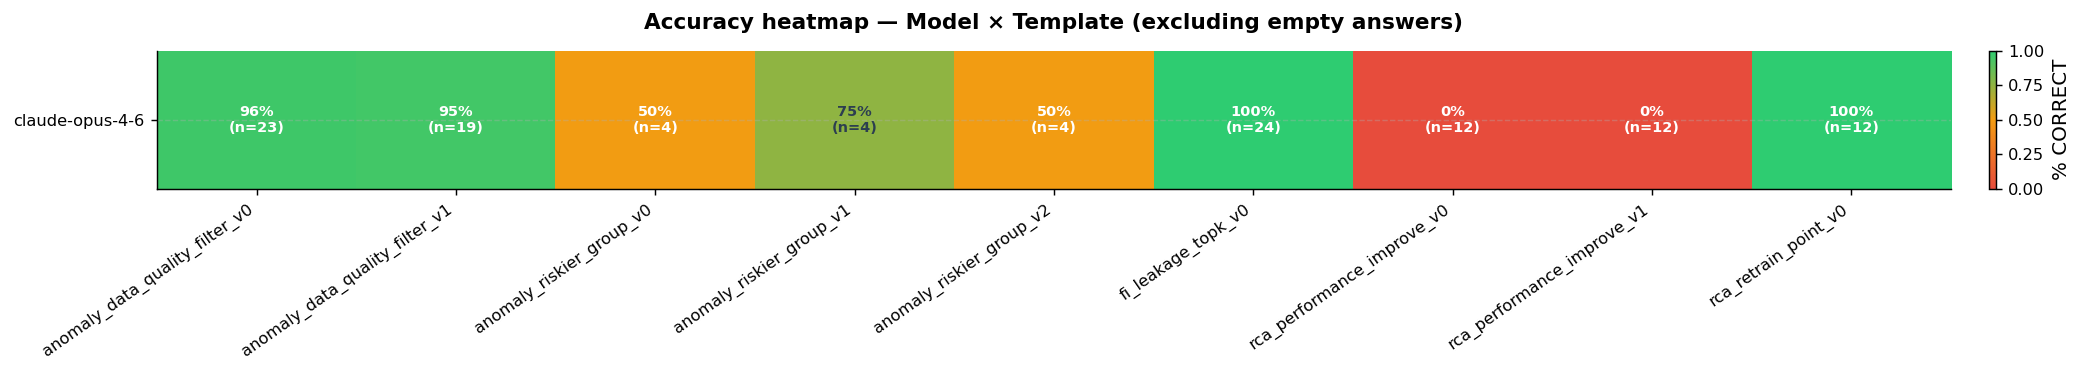

In [34]:
models_hm = sorted(df_ok["model"].unique())
templates_hm = sorted(df_ok["template_id"].unique())

matrix = np.full((len(models_hm), len(templates_hm)), np.nan)
counts_hm = np.zeros_like(matrix, dtype=int)

for i, m in enumerate(models_hm):
    for j, t in enumerate(templates_hm):
        sub = df_ok[(df_ok["model"] == m) & (df_ok["template_id"] == t)]
        if len(sub):
            matrix[i, j] = (sub["grade"] == "CORRECT").mean()
            counts_hm[i, j] = len(sub)

cmap = LinearSegmentedColormap.from_list("rg", ["#e74c3c", "#f39c12", "#2ecc71"], N=256)

fig, ax = plt.subplots(
    figsize=(max(8, len(templates_hm) * 1.8), max(3, len(models_hm) * 0.9 + 1))
)
im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(templates_hm)))
ax.set_xticklabels(templates_hm, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(models_hm)))
ax.set_yticklabels(models_hm, fontsize=9)

for i in range(len(models_hm)):
    for j in range(len(templates_hm)):
        v = matrix[i, j]
        n = counts_hm[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\n(n={n})", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if v < 0.55 or v > 0.75 else "#2c3e50")

plt.colorbar(im, ax=ax, label="% CORRECT", fraction=0.03, pad=0.02)
ax.set_title("Accuracy heatmap — Model × Template (excluding empty answers)", pad=12)
plt.tight_layout()
plt.show()

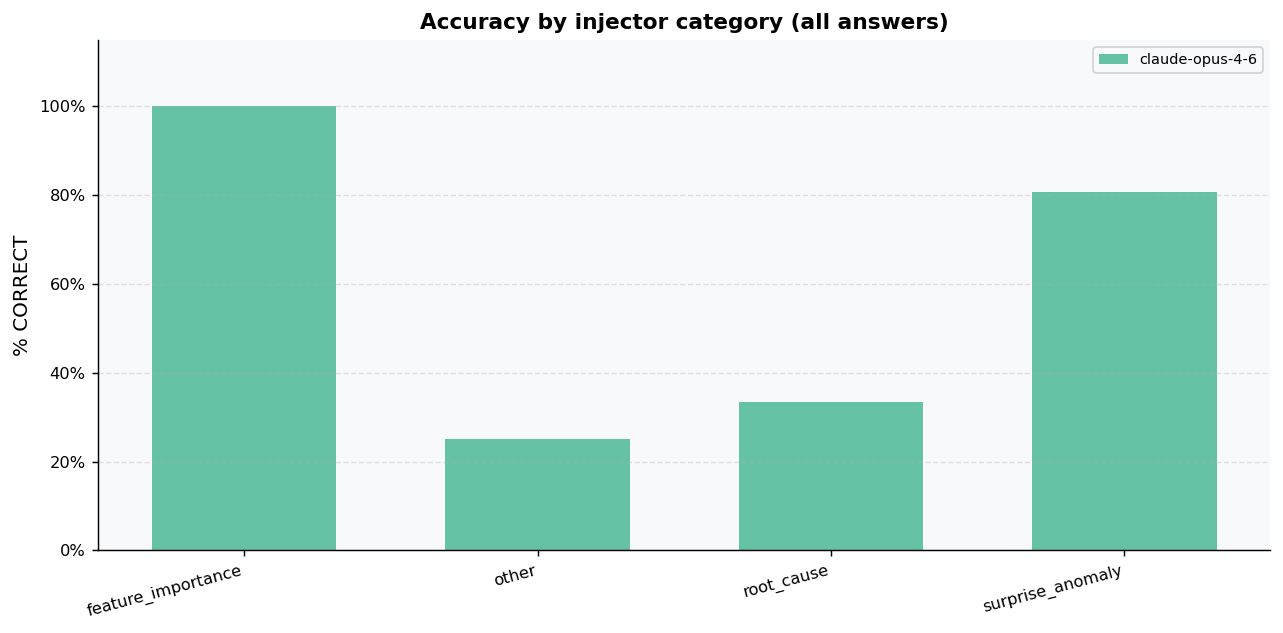

In [35]:
# Accuracy by injector category — ALL answers (empty answers count as not CORRECT)
categories_all = sorted(df["category"].unique())
models_cat_all = sorted(df["model"].unique())
CAT_PALETTE_ALL = plt.cm.Set2(np.linspace(0, 0.8, len(models_cat_all)))

fig, ax = plt.subplots(figsize=(10, 5))
n_cats = len(categories_all)
n_mdls = len(models_cat_all)
bar_w = 0.7 / max(n_mdls, 1)
x = np.arange(n_cats)

for mi, m in enumerate(models_cat_all):
    accs = []
    for c in categories_all:
        sub = df[(df["model"] == m) & (df["category"] == c)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_mdls / 2 + 0.5) * bar_w
    ax.bar(x + offset, accs, width=bar_w * 0.9, color=CAT_PALETTE_ALL[mi], label=m)

ax.set_xticks(x)
ax.set_xticklabels(categories_all, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by injector category (all answers)")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)
plt.tight_layout()
plt.show()

---
## 5 — Accuracy by Dataset Size

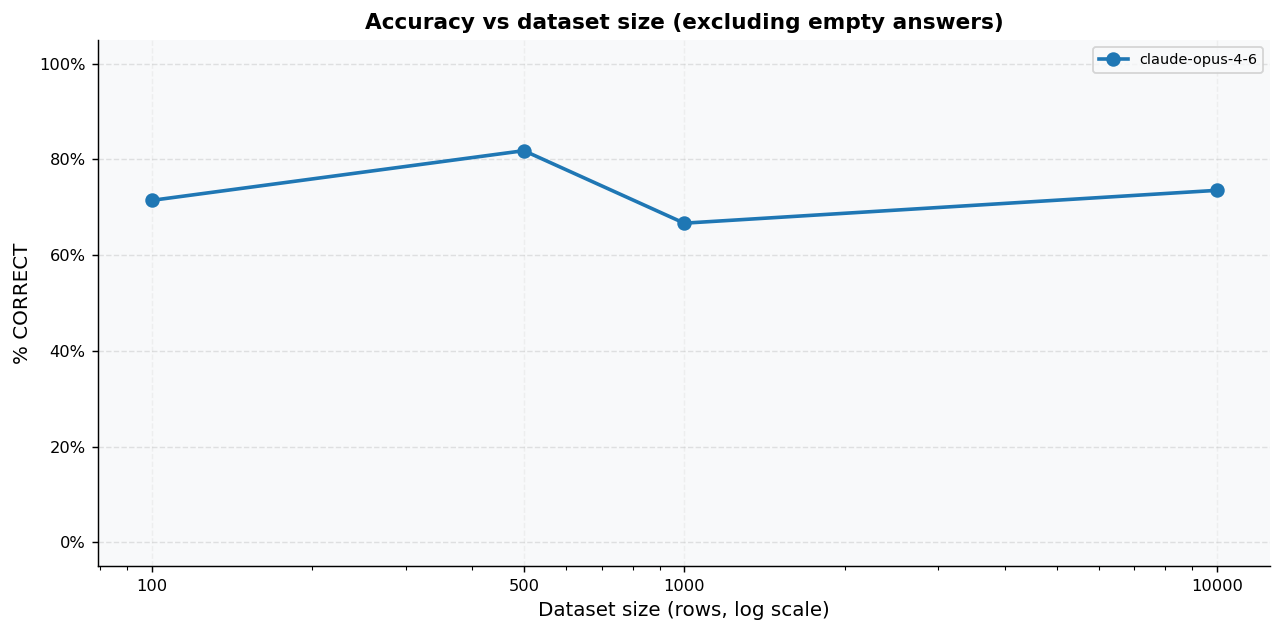

In [36]:
sizes = sorted(df_ok["dataset_size"].dropna().unique().astype(int))
models_sz = sorted(df_ok["model"].unique())
MODEL_COLORS = plt.cm.tab10(np.linspace(0, 0.7, len(models_sz)))

if len(sizes) < 2:
    print("Only one dataset size after excluding errors — skipping.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for mi, m in enumerate(models_sz):
        accs = []
        for s in sizes:
            sub = df_ok[(df_ok["model"] == m) & (df_ok["dataset_size"] == s)]
            accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
        ax.plot(sizes, accs, "o-", color=MODEL_COLORS[mi], label=m, linewidth=2, markersize=7)

    ax.set_xscale("log")
    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Dataset size (rows, log scale)")
    ax.set_ylabel("% CORRECT")
    ax.set_title("Accuracy vs dataset size (excluding empty answers)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.15)
    plt.tight_layout()
    plt.show()

---
## 6 — Accuracy by Injector Category

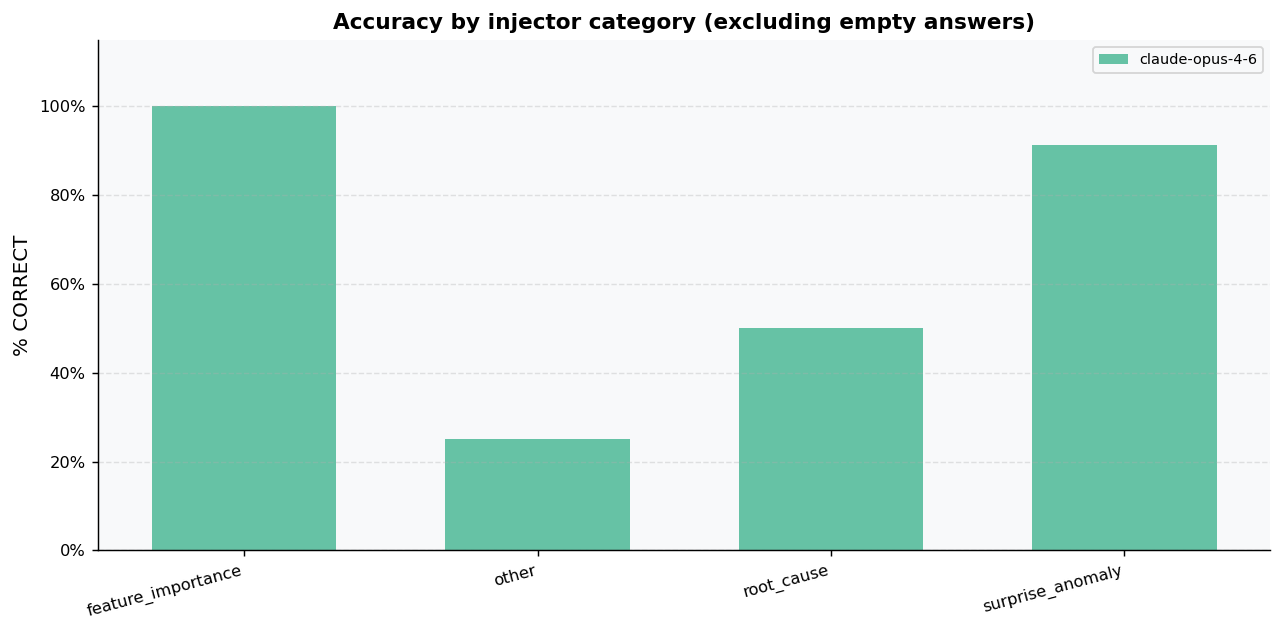

In [37]:
categories_ok = sorted(df_ok["category"].unique())
models_cat = sorted(df_ok["model"].unique())
CAT_PALETTE = plt.cm.Set2(np.linspace(0, 0.8, len(models_cat)))

fig, ax = plt.subplots(figsize=(10, 5))
n_cats = len(categories_ok)
n_mdls = len(models_cat)
bar_w = 0.7 / max(n_mdls, 1)
x = np.arange(n_cats)

for mi, m in enumerate(models_cat):
    accs = []
    for c in categories_ok:
        sub = df_ok[(df_ok["model"] == m) & (df_ok["category"] == c)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_mdls / 2 + 0.5) * bar_w
    ax.bar(x + offset, accs, width=bar_w * 0.9, color=CAT_PALETTE[mi], label=m)

ax.set_xticks(x)
ax.set_xticklabels(categories_ok, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by injector category (excluding empty answers)")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)
plt.tight_layout()
plt.show()

---
## 7 — Empty Answer Analysis

Empty answers: 18 / 132 (13.6%)
Affected datasets: ['bike_sharing_500', 'california_housing_100', 'california_housing_1000', 'california_housing_10000', 'california_housing_500', 'vgsales_100', 'vgsales_1000', 'vgsales_500']



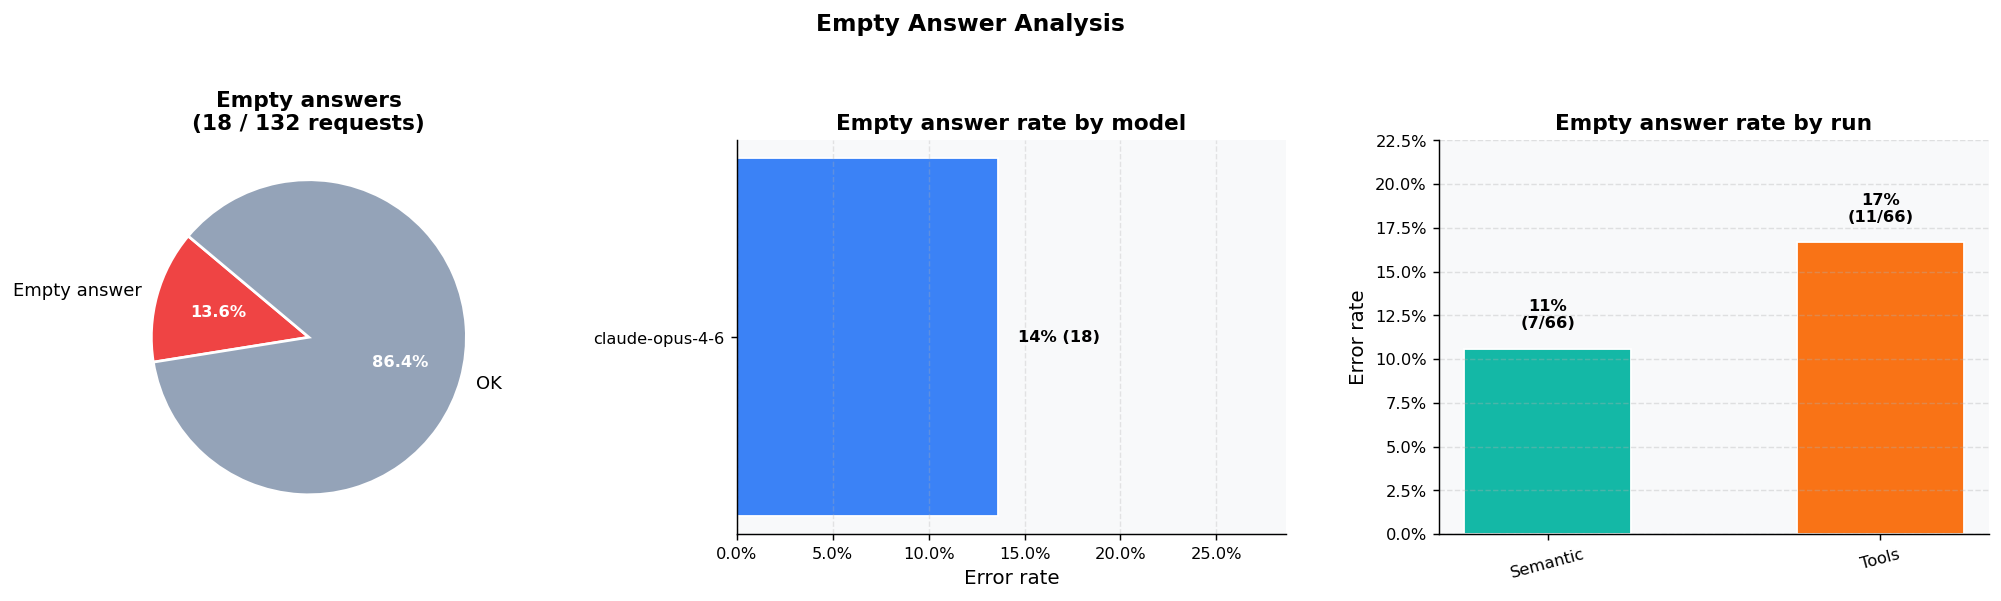


Empty answers by model × run:
                          errors  total rate
model           run                         
claude-opus-4-6 semantic       7     66  11%
                tools         11     66  17%

Empty answers by dataset:

                          errors  total  rate rate_fmt
dataset                                               
california_housing_100         3      8  0.38      38%
vgsales_100                    1     12  0.08       8%
bike_sharing_100               0     12  0.00       0%
bike_sharing_500               2      8  0.25      25%
california_housing_500         2      8  0.25      25%
vgsales_500                    2     12  0.17      17%
california_housing_1000        3      8  0.38      38%
vgsales_1000                   1     12  0.08       8%
bike_sharing_1000              0     14  0.00       0%
california_housing_10000       4      8  0.50      50%
bike_sharing_10000             0     18  0.00       0%
vgsales_10000                  0     12  0.00 

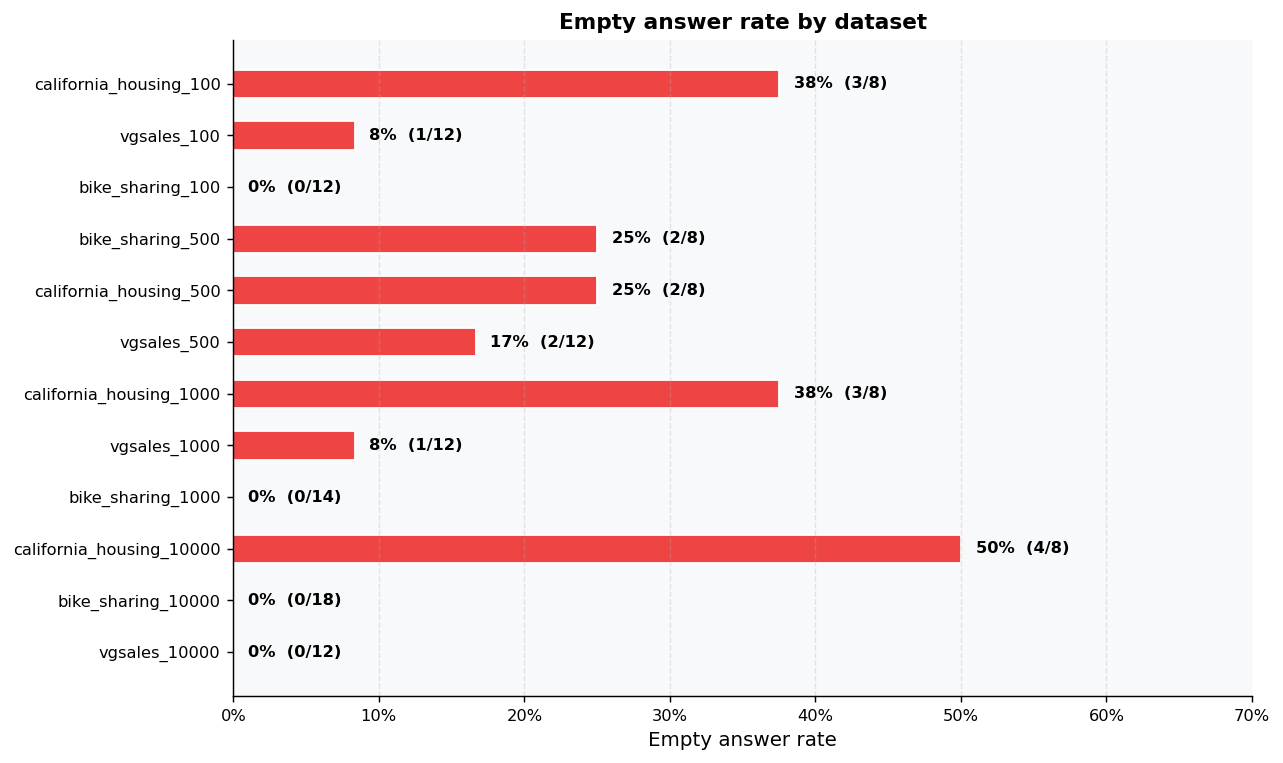

In [38]:
err_df = df[df["is_empty_answer"]]
total_errors = len(err_df)
print(f"Empty answers: {total_errors} / {len(df)} ({total_errors/len(df):.1%})")
print(f"Affected datasets: {sorted(err_df['dataset'].unique())}")
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 7a: Overall error rate (pie) ──────────────────────────────────────────
ax = axes[0]
n_ok = len(df) - total_errors
wedges, texts, autotexts = ax.pie(
    [total_errors, n_ok],
    labels=["Empty answer", "OK"],
    colors=["#ef4444", "#94a3b8"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title(f"Empty answers\n({total_errors} / {len(df)} requests)")

# ── 7b: Error rate by model ───────────────────────────────────────────────
ax2 = axes[1]
models_err = sorted(df["model"].unique())
err_rates = []
err_counts = []
for m in models_err:
    sub = df[df["model"] == m]
    n_err = sub["is_empty_answer"].sum()
    err_rates.append(n_err / len(sub))
    err_counts.append(n_err)

colors = [PROVIDER_COLORS[infer_provider(m)] for m in models_err]
bars = ax2.barh(models_err, err_rates, color=colors, height=0.55, edgecolor="white")
for bar, rate, count in zip(bars, err_rates, err_counts):
    if rate > 0:
        ax2.text(rate + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{rate:.0%} ({count})", va="center", fontsize=9, fontweight="bold")
    else:
        ax2.text(0.005, bar.get_y() + bar.get_height() / 2,
                 "0%", va="center", fontsize=9, color="#64748b")

ax2.set_xlim(0, max(err_rates) + 0.15 if max(err_rates) > 0 else 0.1)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_xlabel("Error rate")
ax2.set_title("Empty answer rate by model")
ax2.grid(axis="x", alpha=0.3)
ax2.grid(axis="y", alpha=0)

# ── 7c: Error rate by run ─────────────────────────────────────────────────
ax3 = axes[2]
run_err_rates, run_err_counts, run_totals = [], [], []
for run in present_runs:
    sub = df[df["run"] == run]
    n_err = sub["is_empty_answer"].sum()
    run_err_rates.append(n_err / len(sub) if len(sub) else 0)
    run_err_counts.append(n_err)
    run_totals.append(len(sub))

run_labels_plot = [RUN_LABELS.get(r, r) for r in present_runs]
bars = ax3.bar(run_labels_plot, run_err_rates,
               color=[RUN_COLORS.get(r, "#94a3b8") for r in present_runs],
               width=0.5, edgecolor="white")
for bar, rate, count, total in zip(bars, run_err_rates, run_err_counts, run_totals):
    ax3.text(bar.get_x() + bar.get_width() / 2, rate + 0.01,
             f"{rate:.0%}\n({count}/{total})",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax3.set_ylim(0, max(run_err_rates) * 1.35 if run_err_rates and max(run_err_rates) > 0 else 0.1)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.set_ylabel("Error rate")
ax3.set_title("Empty answer rate by run")
ax3.tick_params(axis="x", rotation=15)
ax3.grid(axis="y", alpha=0.35)
ax3.grid(axis="x", alpha=0)

plt.suptitle("Empty Answer Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Breakdown table ───────────────────────────────────────────────────────
print("\nEmpty answers by model × run:")
pivot = (
    df.groupby(["model", "run"])["is_empty_answer"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "errors", "count": "total"})
)
pivot["rate"] = (pivot["errors"] / pivot["total"]).map("{:.0%}".format)
print(pivot.to_string())

# ── Error rate by dataset (bar chart) ─────────────────────────────────────
ctx_by_ds = (
    df.groupby("dataset")["is_empty_answer"]
    .agg(errors="sum", total="count")
    .assign(rate=lambda x: x["errors"] / x["total"])
)
ctx_by_ds["rate_fmt"] = ctx_by_ds["rate"].map("{:.0%}".format)
ctx_by_ds["_size"] = ctx_by_ds.index.map(_parse_size)
ctx_by_ds = ctx_by_ds.sort_values(["_size", "rate"], ascending=[True, False]).drop(columns="_size")

print("\nEmpty answers by dataset:\n")
print(ctx_by_ds.to_string())
print(f"\nDatasets with errors: {(ctx_by_ds['errors'] > 0).sum()} / {len(ctx_by_ds)}")

plot_order = ctx_by_ds.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, max(3, len(plot_order) * 0.5)))
colors = ["#ef4444" if r > 0 else "#94a3b8" for r in plot_order["rate"]]
bars = ax.barh(plot_order.index, plot_order["rate"], color=colors, height=0.55, edgecolor="white")
for bar, (_, row) in zip(bars, plot_order.iterrows()):
    label = f"{row['rate_fmt']}  ({int(row['errors'])}/{int(row['total'])})"
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, ctx_by_ds["rate"].max() + 0.2 if ctx_by_ds["rate"].max() > 0 else 0.1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Empty answer rate")
ax.set_title("Empty answer rate by dataset")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.show()

---
## 8 — Template × Run Accuracy

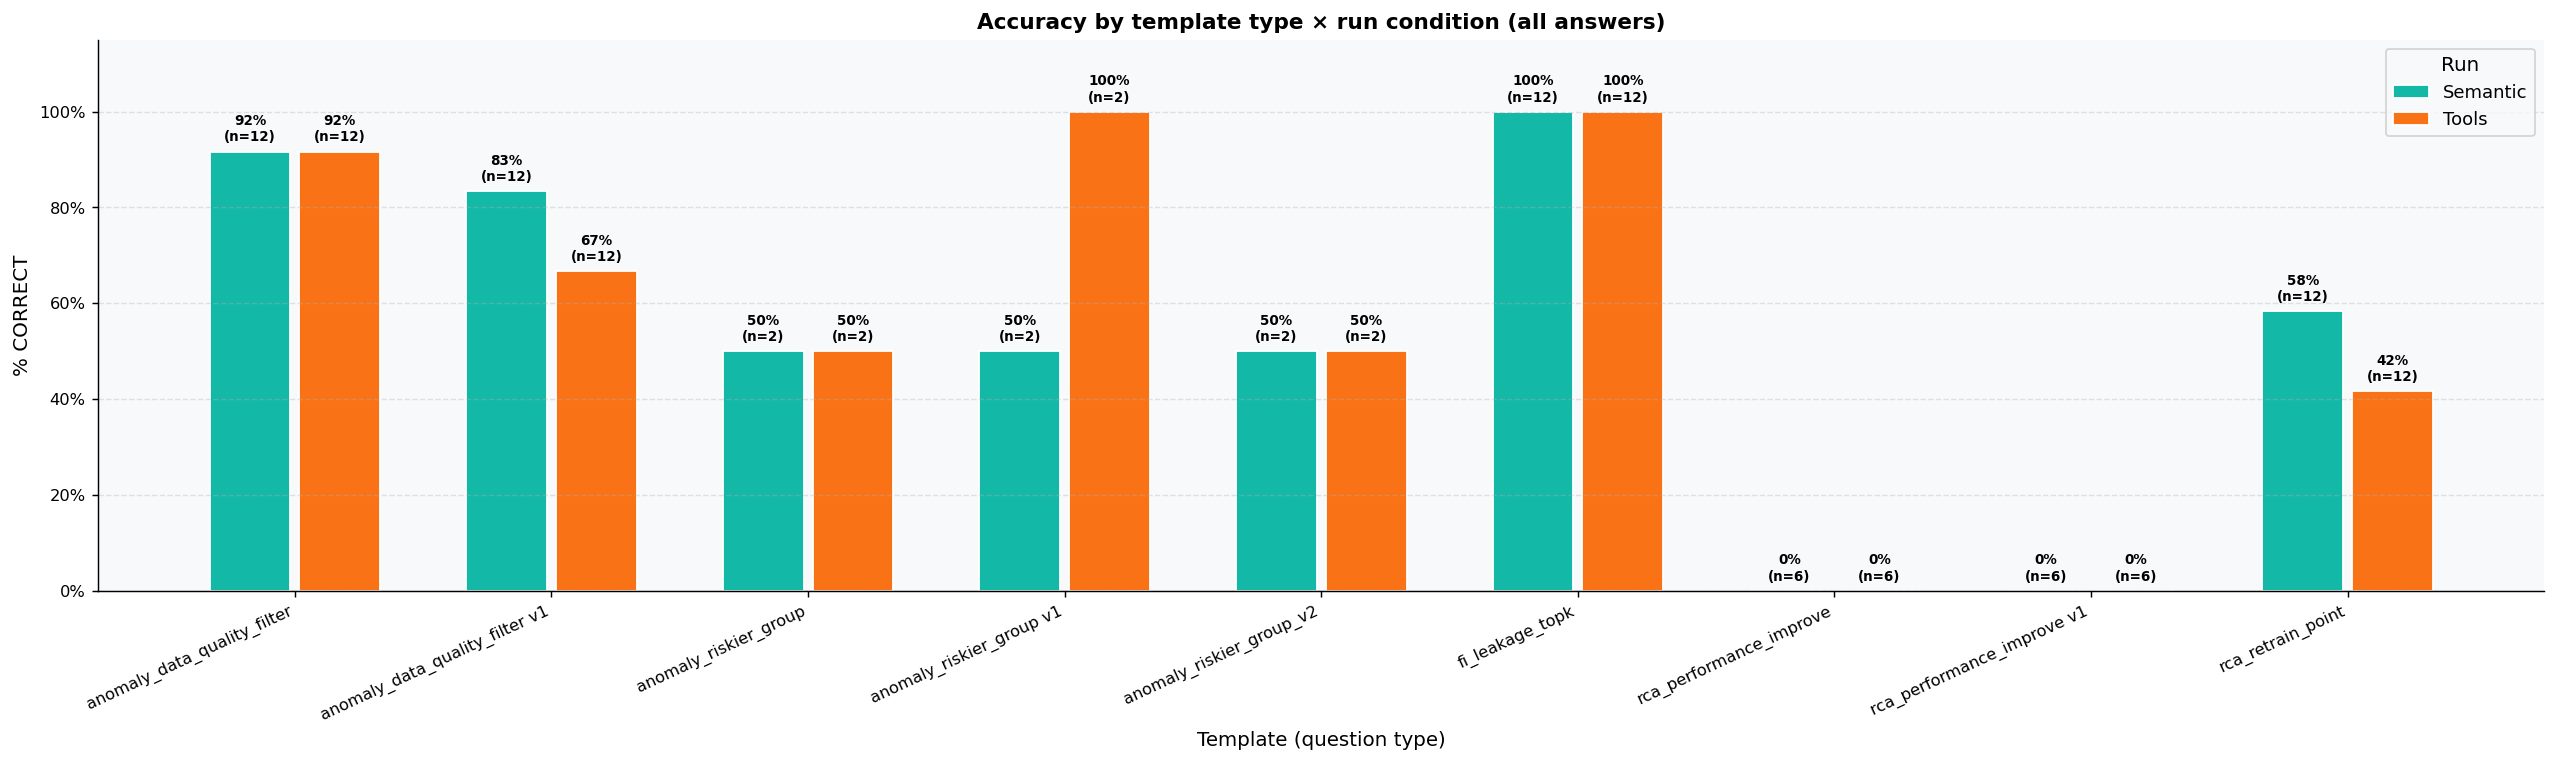

In [39]:
# Template x Run accuracy — ALL answers (empty answers count as not CORRECT)
templates_tr_all = sorted(df["template_id"].unique())
short_labels_all = [t.replace("_v0", "").replace("_v1", " v1") for t in templates_tr_all]

fig, ax = plt.subplots(figsize=(max(10, len(templates_tr_all) * 2.2), 6))

n_templates = len(templates_tr_all)
n_runs = len(present_runs)
bar_w = 0.7 / max(n_runs, 1)
x = np.arange(n_templates)

for ri, run in enumerate(present_runs):
    accs, ns = [], []
    for t in templates_tr_all:
        sub = df[(df["template_id"] == t) & (df["run"] == run)]
        if len(sub):
            accs.append((sub["grade"] == "CORRECT").mean())
            ns.append(len(sub))
        else:
            accs.append(np.nan)
            ns.append(0)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
    for bar, v, n in zip(bars, accs, ns):
        if n > 0 and not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                    f"{v:.0%}\n(n={n})", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(short_labels_all, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_xlabel("Template (question type)")
ax.set_title("Accuracy by template type × run condition (all answers)")
ax.legend(fontsize=10, title="Run")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

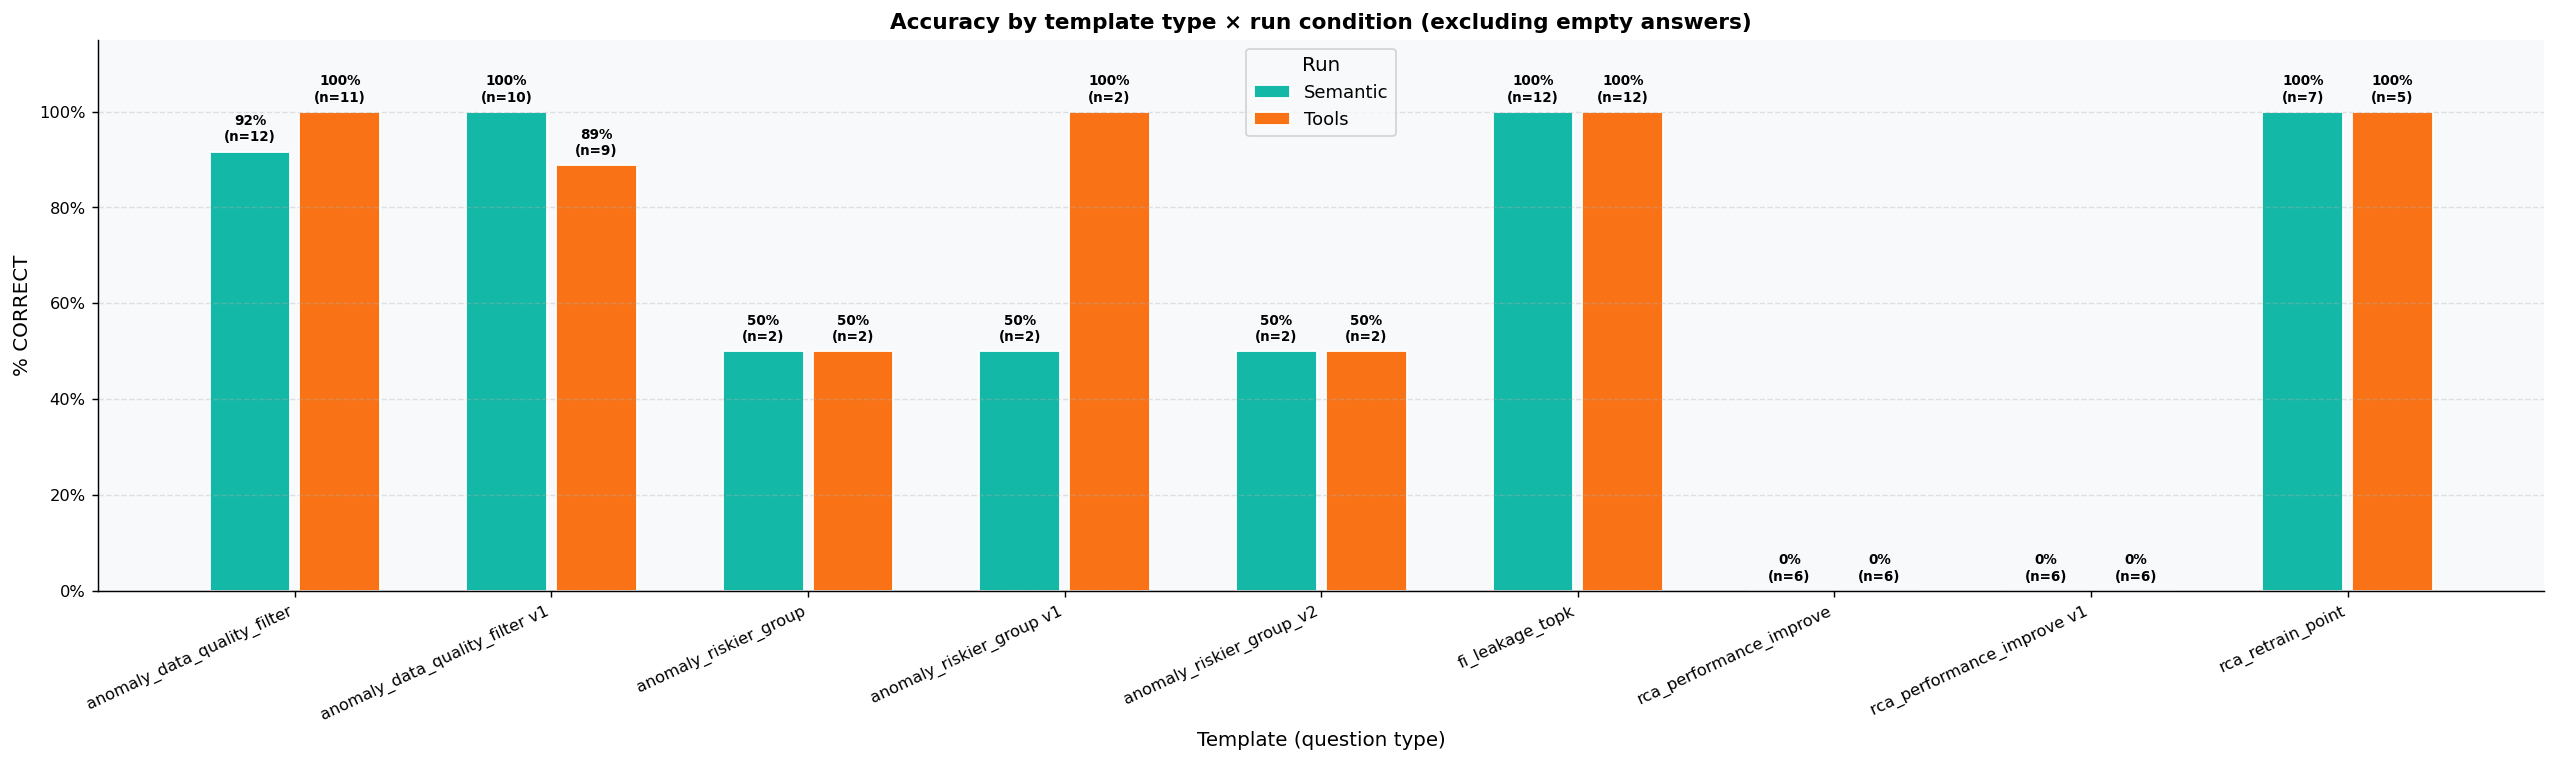

In [40]:
templates_tr = sorted(df_ok["template_id"].unique())
short_labels = [t.replace("_v0", "").replace("_v1", " v1") for t in templates_tr]

fig, ax = plt.subplots(figsize=(max(10, len(templates_tr) * 2.2), 6))

n_templates = len(templates_tr)
n_runs = len(present_runs)
bar_w = 0.7 / max(n_runs, 1)
x = np.arange(n_templates)

for ri, run in enumerate(present_runs):
    accs, ns = [], []
    for t in templates_tr:
        sub = df_ok[(df_ok["template_id"] == t) & (df_ok["run"] == run)]
        if len(sub):
            accs.append((sub["grade"] == "CORRECT").mean())
            ns.append(len(sub))
        else:
            accs.append(np.nan)
            ns.append(0)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
    for bar, v, n in zip(bars, accs, ns):
        if n > 0 and not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                    f"{v:.0%}\n(n={n})", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_xlabel("Template (question type)")
ax.set_title("Accuracy by template type × run condition (excluding empty answers)")
ax.legend(fontsize=10, title="Run")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

---
## 9 — Latency & Token Metrics

All charts use **median** values (robust to outliers). Error entries are excluded.
Metrics: `total_latency_s` (wall-clock), `ttft_s` (time-to-first-token), `input_tokens`, `output_tokens`.

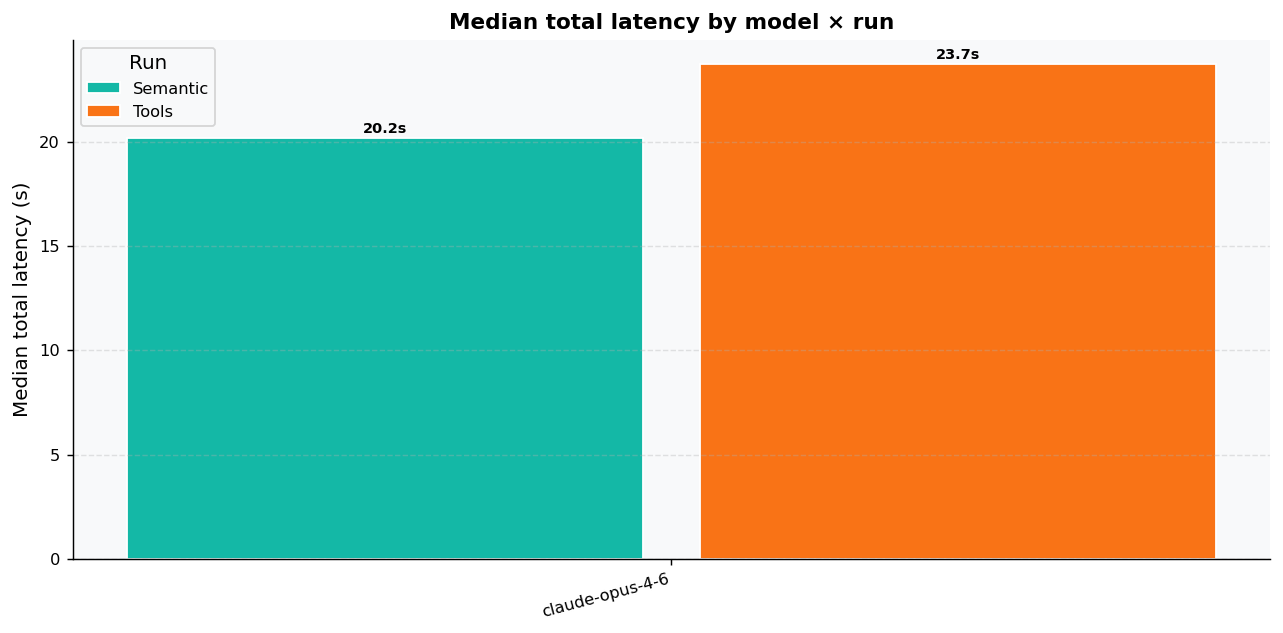

No TTFT data available.


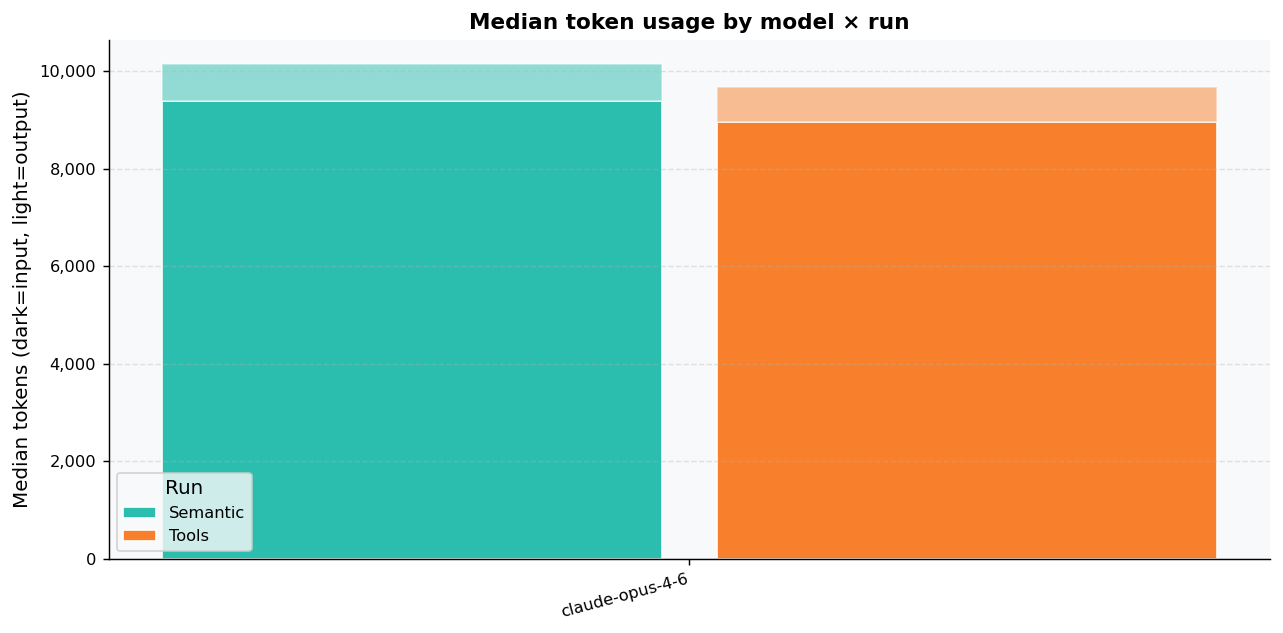

Median metrics per run × model (errors excluded):

                           n  total_latency_s ttft_s  input_tokens  output_tokens  total_tokens
run      model                                                                                 
Semantic claude-opus-4-6  59            20.17   None       9393.00         747.00      10313.00
Tools    claude-opus-4-6  55            23.71   None       8962.00         719.00       9815.00


In [41]:
# ── 9a: Median total latency — model × run ───────────────────────────────
df_lat = df_ok[df_ok.get("total_latency_s", pd.Series(dtype=float)).notna() & ~df_ok["is_error"]].copy()

if "total_latency_s" not in df_ok.columns or df_lat.empty:
    print("No latency data available.")
else:
    models_lat = sorted(df_lat["model"].unique())
    runs_lat = [r for r in present_runs if len(df_lat[df_lat["run"] == r]) > 0]

    fig, ax = plt.subplots(figsize=(max(10, len(models_lat) * 1.4), 5))
    n_models = len(models_lat)
    n_runs = len(runs_lat)
    bar_w = 0.7 / max(n_runs, 1)
    x = np.arange(n_models)

    for ri, run in enumerate(runs_lat):
        medians = []
        for m in models_lat:
            sub = df_lat[(df_lat["model"] == m) & (df_lat["run"] == run)]["total_latency_s"]
            medians.append(sub.median() if len(sub) else np.nan)
        offset = (ri - n_runs / 2 + 0.5) * bar_w
        label = RUN_LABELS.get(run, run)
        color = RUN_COLORS.get(run, "#94a3b8")
        bars = ax.bar(x + offset, medians, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
        for bar, v in zip(bars, medians):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                        f"{v:.1f}s", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(models_lat, rotation=15, ha="right")
    ax.set_ylabel("Median total latency (s)")
    ax.set_title("Median total latency by model × run")
    ax.legend(fontsize=9, title="Run")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)
    plt.tight_layout()
    plt.show()

# ── 9b: Median TTFT — model × run ────────────────────────────────────────
if "ttft_s" in df_ok.columns:
    df_ttft = df_ok[df_ok["ttft_s"].notna() & ~df_ok["is_error"]].copy()
else:
    df_ttft = pd.DataFrame()

if df_ttft.empty:
    print("No TTFT data available.")
else:
    models_t = sorted(df_ttft["model"].unique())
    runs_t = [r for r in present_runs if df_ttft[df_ttft["run"] == r]["ttft_s"].notna().any()]

    fig, ax = plt.subplots(figsize=(max(10, len(models_t) * 1.4), 5))
    n_models = len(models_t)
    n_runs = len(runs_t)
    bar_w = 0.7 / max(n_runs, 1)
    x = np.arange(n_models)

    for ri, run in enumerate(runs_t):
        medians = []
        for m in models_t:
            sub = df_ttft[(df_ttft["model"] == m) & (df_ttft["run"] == run)]["ttft_s"]
            medians.append(sub.median() if len(sub) else np.nan)
        offset = (ri - n_runs / 2 + 0.5) * bar_w
        label = RUN_LABELS.get(run, run)
        color = RUN_COLORS.get(run, "#94a3b8")
        bars = ax.bar(x + offset, medians, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
        for bar, v in zip(bars, medians):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                        f"{v:.1f}s", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(models_t, rotation=15, ha="right")
    ax.set_ylabel("Median TTFT (s)")
    ax.set_title("Median time-to-first-token by model × run")
    ax.legend(fontsize=9, title="Run")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)
    plt.tight_layout()
    plt.show()

# ── 9c: Median token usage — model × run (stacked input + output) ────────
if "input_tokens" in df_ok.columns:
    df_tok = df_ok[df_ok["input_tokens"].notna() & ~df_ok["is_error"]].copy()
else:
    df_tok = pd.DataFrame()

if df_tok.empty:
    print("No token data available.")
else:
    models_tk = sorted(df_tok["model"].unique())
    runs_tk = [r for r in present_runs if len(df_tok[df_tok["run"] == r]) > 0]

    fig, ax = plt.subplots(figsize=(max(10, len(models_tk) * 1.4), 5))
    n_models = len(models_tk)
    n_runs = len(runs_tk)
    bar_w = 0.7 / max(n_runs, 1)
    x = np.arange(n_models)

    for ri, run in enumerate(runs_tk):
        med_in, med_out = [], []
        for m in models_tk:
            sub = df_tok[(df_tok["model"] == m) & (df_tok["run"] == run)]
            med_in.append(sub["input_tokens"].median() if len(sub) else np.nan)
            med_out.append(sub["output_tokens"].median() if len(sub) else np.nan)

        offset = (ri - n_runs / 2 + 0.5) * bar_w
        color = RUN_COLORS.get(run, "#94a3b8")
        label = RUN_LABELS.get(run, run)
        ax.bar(x + offset, med_in, width=bar_w * 0.9, color=color,
               label=label, edgecolor="white", alpha=0.9)
        ax.bar(x + offset, med_out, width=bar_w * 0.9, color=color,
               bottom=med_in, edgecolor="white", alpha=0.45)

    ax.set_xticks(x)
    ax.set_xticklabels(models_tk, rotation=15, ha="right")
    ax.set_ylabel("Median tokens (dark=input, light=output)")
    ax.set_title("Median token usage by model × run")
    ax.legend(fontsize=9, title="Run")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)
    plt.tight_layout()
    plt.show()

# ── 9d: Summary metrics table ─────────────────────────────────────────────
metrics_cols = [c for c in ["total_latency_s", "ttft_s", "input_tokens", "output_tokens", "total_tokens"]
                if c in df_ok.columns]
if metrics_cols:
    df_m = df_ok[~df_ok["is_error"]].copy()
    rows = []
    for run in present_runs:
        for m in sorted(df_m["model"].unique()):
            sub = df_m[(df_m["run"] == run) & (df_m["model"] == m)]
            if sub.empty:
                continue
            row = {"run": RUN_LABELS.get(run, run), "model": m, "n": len(sub)}
            for col in metrics_cols:
                valid = sub[col].dropna()
                row[col] = round(valid.median(), 2) if len(valid) else None
            rows.append(row)
    summary = pd.DataFrame(rows).set_index(["run", "model"])
    pd.set_option("display.float_format", "{:.2f}".format)
    pd.set_option("display.max_rows", 100)
    print("Median metrics per run × model (errors excluded):\n")
    print(summary.to_string())

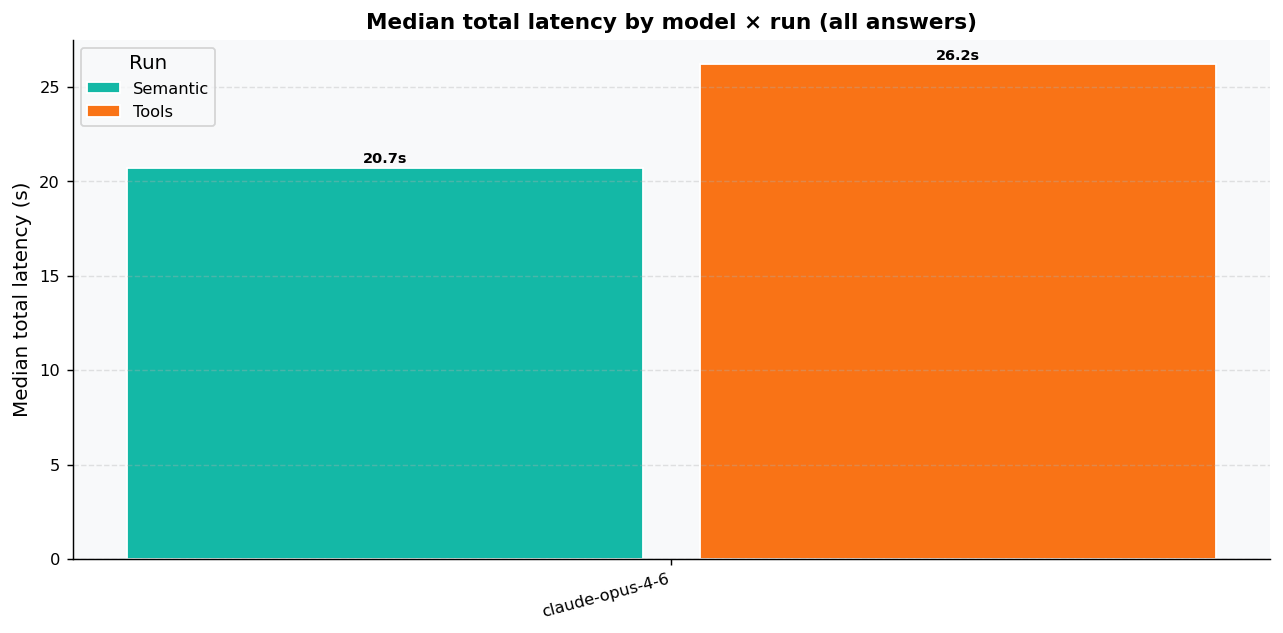

In [42]:
# Median total latency by model × run — ALL answers (including empty/errors)
if "total_latency_s" not in df.columns or df["total_latency_s"].notna().sum() == 0:
    print("No latency data available.")
else:
    df_lat_all = df[df["total_latency_s"].notna()].copy()
    models_lat_all = sorted(df_lat_all["model"].unique())
    runs_lat_all = [r for r in present_runs if len(df_lat_all[df_lat_all["run"] == r]) > 0]

    fig, ax = plt.subplots(figsize=(max(10, len(models_lat_all) * 1.4), 5))
    n_models = len(models_lat_all)
    n_runs = len(runs_lat_all)
    bar_w = 0.7 / max(n_runs, 1)
    x = np.arange(n_models)

    for ri, run in enumerate(runs_lat_all):
        medians = []
        for m in models_lat_all:
            sub = df_lat_all[(df_lat_all["model"] == m) & (df_lat_all["run"] == run)]["total_latency_s"]
            medians.append(sub.median() if len(sub) else np.nan)
        offset = (ri - n_runs / 2 + 0.5) * bar_w
        label = RUN_LABELS.get(run, run)
        color = RUN_COLORS.get(run, "#94a3b8")
        bars = ax.bar(x + offset, medians, width=bar_w * 0.9, label=label, color=color, edgecolor="white")
        for bar, v in zip(bars, medians):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                        f"{v:.1f}s", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(models_lat_all, rotation=15, ha="right")
    ax.set_ylabel("Median total latency (s)")
    ax.set_title("Median total latency by model × run (all answers)")
    ax.legend(fontsize=9, title="Run")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)
    plt.tight_layout()
    plt.show()

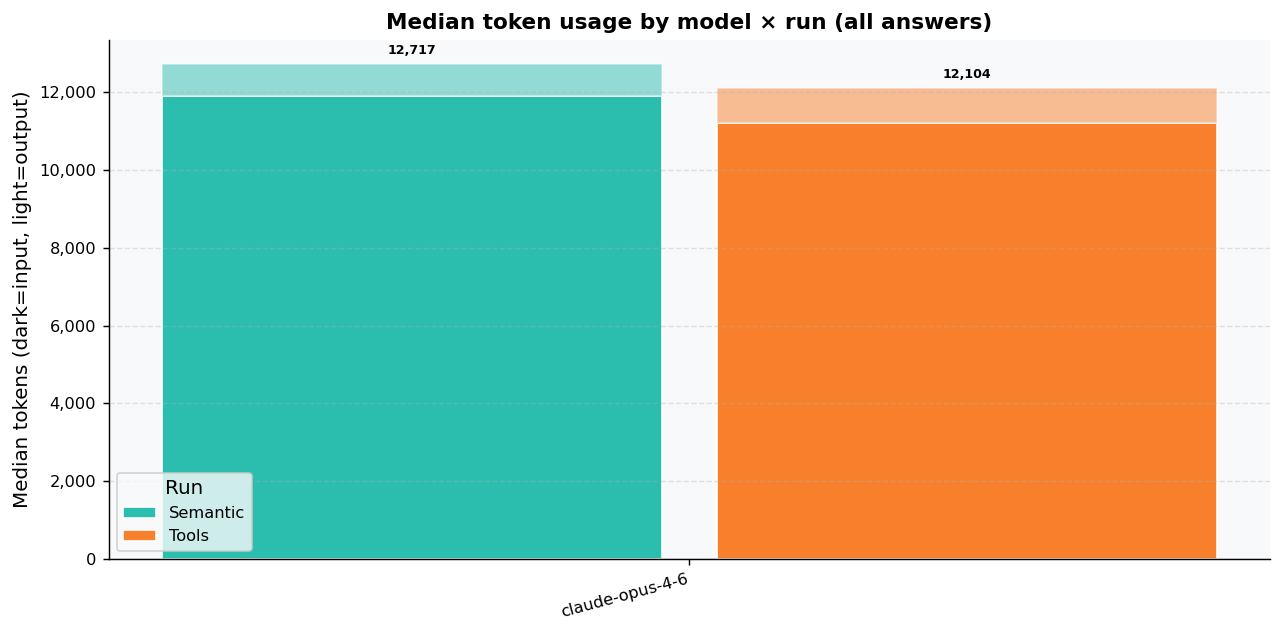

In [43]:
# Median token usage by model × run — ALL answers (including empty/errors)
if "input_tokens" not in df.columns or df["input_tokens"].notna().sum() == 0:
    print("No token data available.")
else:
    df_tok_all = df[df["input_tokens"].notna()].copy()
    models_tk_all = sorted(df_tok_all["model"].unique())
    runs_tk_all = [r for r in present_runs if len(df_tok_all[df_tok_all["run"] == r]) > 0]

    fig, ax = plt.subplots(figsize=(max(10, len(models_tk_all) * 1.4), 5))
    n_models = len(models_tk_all)
    n_runs = len(runs_tk_all)
    bar_w = 0.7 / max(n_runs, 1)
    x = np.arange(n_models)

    for ri, run in enumerate(runs_tk_all):
        med_in, med_out = [], []
        for m in models_tk_all:
            sub = df_tok_all[(df_tok_all["model"] == m) & (df_tok_all["run"] == run)]
            med_in.append(sub["input_tokens"].median() if len(sub) else np.nan)
            med_out.append(sub["output_tokens"].median() if len(sub) else np.nan)

        offset = (ri - n_runs / 2 + 0.5) * bar_w
        color = RUN_COLORS.get(run, "#94a3b8")
        label = RUN_LABELS.get(run, run)
        ax.bar(x + offset, med_in, width=bar_w * 0.9, color=color,
               label=label, edgecolor="white", alpha=0.9)
        ax.bar(x + offset, med_out, width=bar_w * 0.9, color=color,
               bottom=med_in, edgecolor="white", alpha=0.45)

        # Label total on top
        for xi, (mi, mo) in enumerate(zip(med_in, med_out)):
            if not np.isnan(mi):
                total = mi + (mo if not np.isnan(mo) else 0)
                ax.text(x[xi] + offset, total + 200,
                        f"{int(total):,}", ha="center", va="bottom",
                        fontsize=7, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(models_tk_all, rotation=15, ha="right")
    ax.set_ylabel("Median tokens (dark=input, light=output)")
    ax.set_title("Median token usage by model × run (all answers)")
    ax.legend(fontsize=9, title="Run")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)
    plt.tight_layout()
    plt.show()

---
## 10 — Semantic Tool Usage Deep Dive

In [ ]:
# Median token usage by template type × run condition — ALL answers
if "input_tokens" not in df.columns or df["input_tokens"].notna().sum() == 0:
    print("No token data available.")
else:
    df_tok = df[df["input_tokens"].notna()].copy()
    templates_tok = sorted(df_tok["template_id"].unique())
    runs_tok = [r for r in present_runs if r in df_tok["run"].unique()]

    if not templates_tok or not runs_tok:
        print("Not enough template/run combinations with token data.")
    else:
        # Build median total-tokens matrix (template × run)
        matrix = np.full((len(templates_tok), len(runs_tok)), np.nan)
        for ti, tmpl in enumerate(templates_tok):
            for ri, run in enumerate(runs_tok):
                sub = df_tok[(df_tok["template_id"] == tmpl) & (df_tok["run"] == run)]
                if len(sub):
                    matrix[ti, ri] = sub["input_tokens"].median() + sub["output_tokens"].fillna(0).median()

        short_templates = [t.replace("_v0", "").replace("_v1", " v1") for t in templates_tok]
        run_labels = [RUN_LABELS.get(r, r) for r in runs_tok]

        fig, ax = plt.subplots(figsize=(max(8, len(runs_tok) * 1.8), max(4, len(templates_tok) * 0.7)))
        im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")

        ax.set_xticks(range(len(runs_tok)))
        ax.set_xticklabels(run_labels, rotation=30, ha="right")
        ax.set_yticks(range(len(templates_tok)))
        ax.set_yticklabels(short_templates)

        # Annotate cells
        for ti in range(len(templates_tok)):
            for ri in range(len(runs_tok)):
                val = matrix[ti, ri]
                if not np.isnan(val):
                    text_color = "white" if val > np.nanmedian(matrix) else "black"
                    ax.text(ri, ti, f"{int(val):,}", ha="center", va="center",
                            fontsize=9, fontweight="bold", color=text_color)

        ax.set_title("Median total token usage by template × run (all answers)")
        fig.colorbar(im, ax=ax, label="Median tokens", shrink=0.8)
        plt.tight_layout()
        plt.show()

Entries in semantic run       : 66
Entries with 0 tool calls     : 0  (0.0%)
Total tool calls made         : 358
Median calls per entry        : 5.0
Max calls per entry           : 14

Calls per entry by model:
                 median  mean  max  zero_calls
model                                         
claude-opus-4-6    5.00  5.42   14           0

Component breakdown (all entries):
component
?                          198
overview                    54
shape_function              50
interaction_importances     26
feature_importances         24
interaction_surface          6


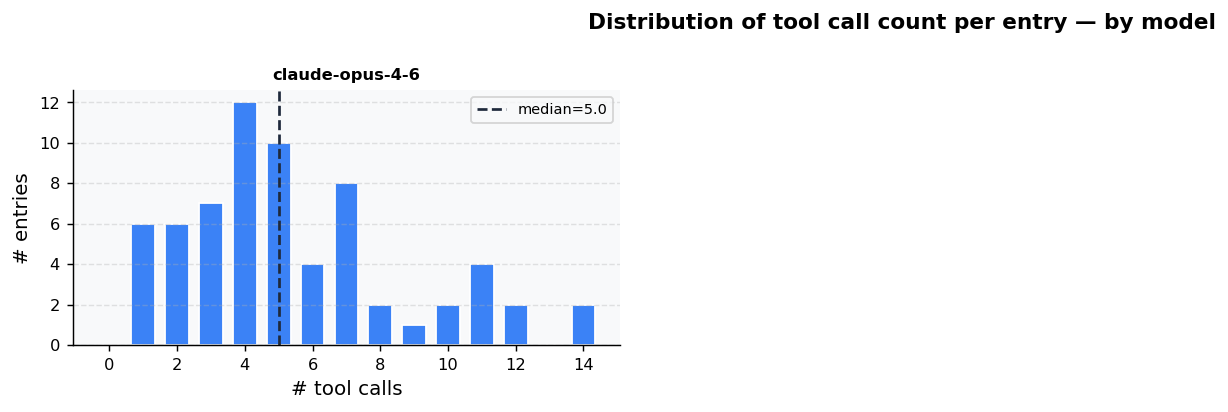

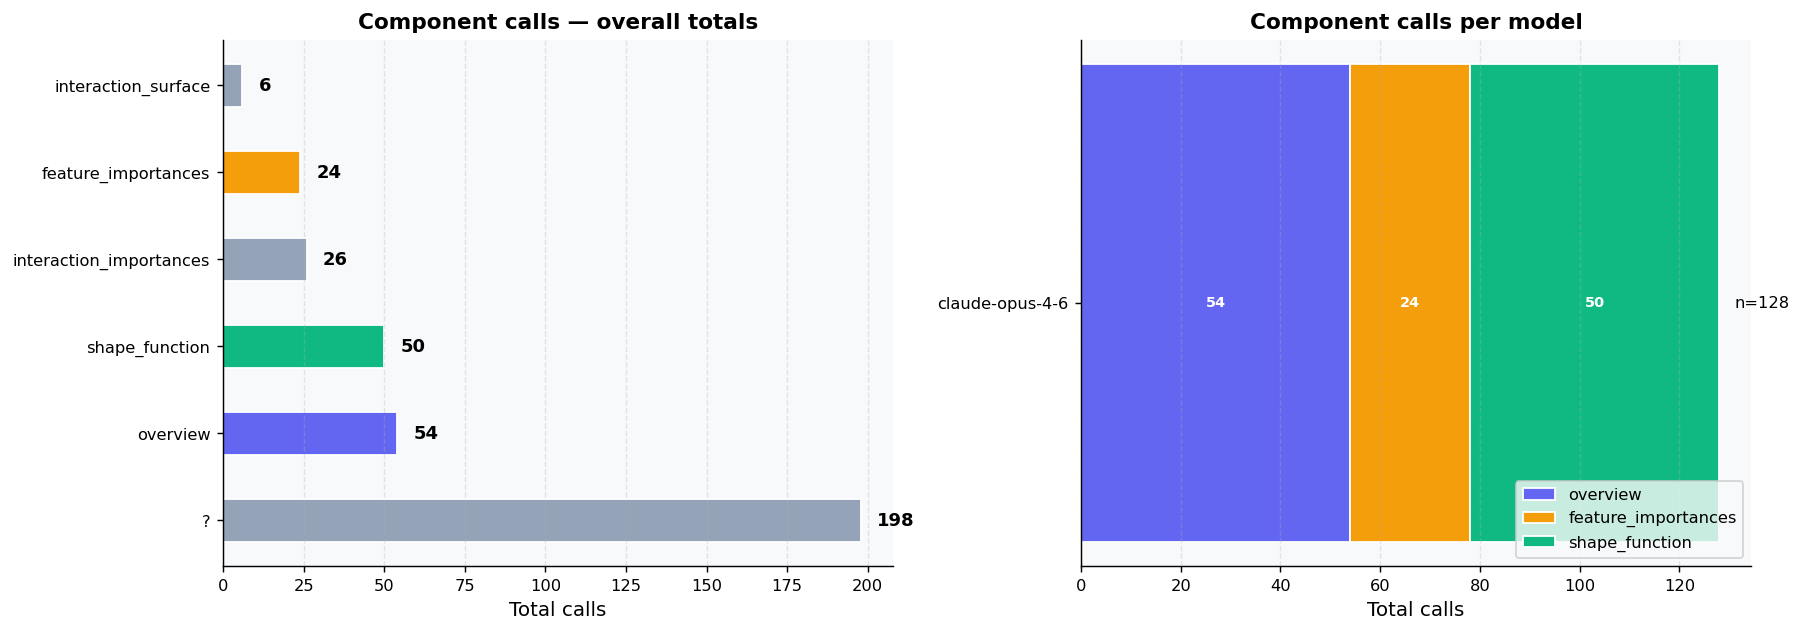

In [44]:
# ── Setup: extract semantic run tool usage ────────────────────────────────
df_sem = df[df["run"].isin({"semantic_only", "semantic"})].copy()

if df_sem.empty:
    print("No semantic run data found.")
else:
    # Flatten tool_use list into per-call rows
    tool_rows = []
    for _, row in df_sem.iterrows():
        calls = row.get("tool_use") or []
        for call in calls:
            inp = call.get("input", {})
            if isinstance(inp, str):
                inp = {}
            tool_rows.append({
                "model":       row["model"],
                "template_id": row["template_id"],
                "category":    row["category"],
                "dataset":     row["dataset"],
                "grade":       row.get("grade"),
                "tool":        call.get("tool", "?"),
                "component":   inp.get("component", "?"),
                "feature":     inp.get("feature"),
            })
    df_calls = pd.DataFrame(tool_rows)

    # Per-entry call count
    df_sem["n_calls"] = df_sem["tool_use"].apply(lambda x: len(x) if isinstance(x, list) else 0)

    total_entries = len(df_sem)
    zero_call_entries = (df_sem["n_calls"] == 0).sum()
    total_calls = df_sem["n_calls"].sum()

    print(f"Entries in semantic run       : {total_entries}")
    print(f"Entries with 0 tool calls     : {zero_call_entries}  ({zero_call_entries/total_entries:.1%})")
    print(f"Total tool calls made         : {int(total_calls)}")
    print(f"Median calls per entry        : {df_sem['n_calls'].median():.1f}")
    print(f"Max calls per entry           : {int(df_sem['n_calls'].max())}")
    print()
    print("Calls per entry by model:")
    print(df_sem.groupby("model")["n_calls"].agg(["median", "mean", "max", lambda x: (x==0).sum()])
          .rename(columns={"median": "median", "mean": "mean", "max": "max", "<lambda_0>": "zero_calls"})
          .to_string())
    print()
    if not df_calls.empty:
        print("Component breakdown (all entries):")
        print(df_calls["component"].value_counts().to_string())

    # ── 10a: Tool call count distribution — histogram per model ────────────
    models_sem = sorted(df_sem["model"].unique())
    n_cols = 3
    n_rows_grid = (len(models_sem) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(14, n_rows_grid * 3.2), sharey=False)
    if n_rows_grid == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    for i, m in enumerate(models_sem):
        ax = axes_flat[i]
        vals = df_sem[df_sem["model"] == m]["n_calls"]
        max_v = int(vals.max()) if len(vals) else 1
        bins = range(0, max_v + 2)
        ax.hist(vals, bins=bins, color=PROVIDER_COLORS[infer_provider(m)],
                edgecolor="white", align="left", rwidth=0.7)
        ax.axvline(vals.median(), color="#1e293b", linestyle="--", linewidth=1.5,
                   label=f"median={vals.median():.1f}")
        ax.set_title(m, fontsize=9)
        ax.set_xlabel("# tool calls")
        ax.set_ylabel("# entries")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.35)
        ax.grid(axis="x", alpha=0)

    for j in range(len(models_sem), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("Distribution of tool call count per entry — by model", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── 10b: Component usage breakdown ────────────────────────────────────
    if not df_calls.empty:
        COMPONENT_COLORS = {
            "overview":            "#6366f1",
            "feature_importances": "#f59e0b",
            "shape_function":      "#10b981",
        }

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Left: overall component totals
        ax = axes[0]
        comp_counts = df_calls["component"].value_counts()
        colors = [COMPONENT_COLORS.get(c, "#94a3b8") for c in comp_counts.index]
        bars = ax.barh(comp_counts.index, comp_counts.values, color=colors, height=0.5, edgecolor="white")
        for bar, v in zip(bars, comp_counts.values):
            ax.text(v + 5, bar.get_y() + bar.get_height() / 2,
                    str(v), va="center", fontsize=10, fontweight="bold")
        ax.set_xlabel("Total calls")
        ax.set_title("Component calls — overall totals")
        ax.grid(axis="x", alpha=0.3)
        ax.grid(axis="y", alpha=0)

        # Right: per-model component breakdown (stacked)
        ax2 = axes[1]
        models_sem_c = sorted(df_calls["model"].unique())
        components = ["overview", "feature_importances", "shape_function"]
        comp_by_model = (
            df_calls.groupby(["model", "component"]).size()
            .unstack(fill_value=0)
            .reindex(columns=components, fill_value=0)
        )
        lefts = np.zeros(len(models_sem_c))
        for comp in components:
            vals = comp_by_model.loc[models_sem_c, comp].values if comp in comp_by_model.columns else np.zeros(len(models_sem_c))
            color = COMPONENT_COLORS.get(comp, "#94a3b8")
            bars = ax2.barh(models_sem_c, vals, left=lefts, color=color,
                            label=comp, height=0.5, edgecolor="white")
            for bar, v, l in zip(bars, vals, lefts):
                if v > 5:
                    ax2.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                             str(int(v)), ha="center", va="center",
                             fontsize=8, color="white", fontweight="bold")
            lefts = lefts + vals

        for i, m in enumerate(models_sem_c):
            total = int(lefts[i])
            ax2.text(total + 3, i, f"n={total}", va="center", fontsize=9)

        ax2.set_xlabel("Total calls")
        ax2.set_title("Component calls per model")
        ax2.legend(fontsize=9, loc="lower right")
        ax2.grid(axis="x", alpha=0.3)
        ax2.grid(axis="y", alpha=0)

        plt.tight_layout()
        plt.show()

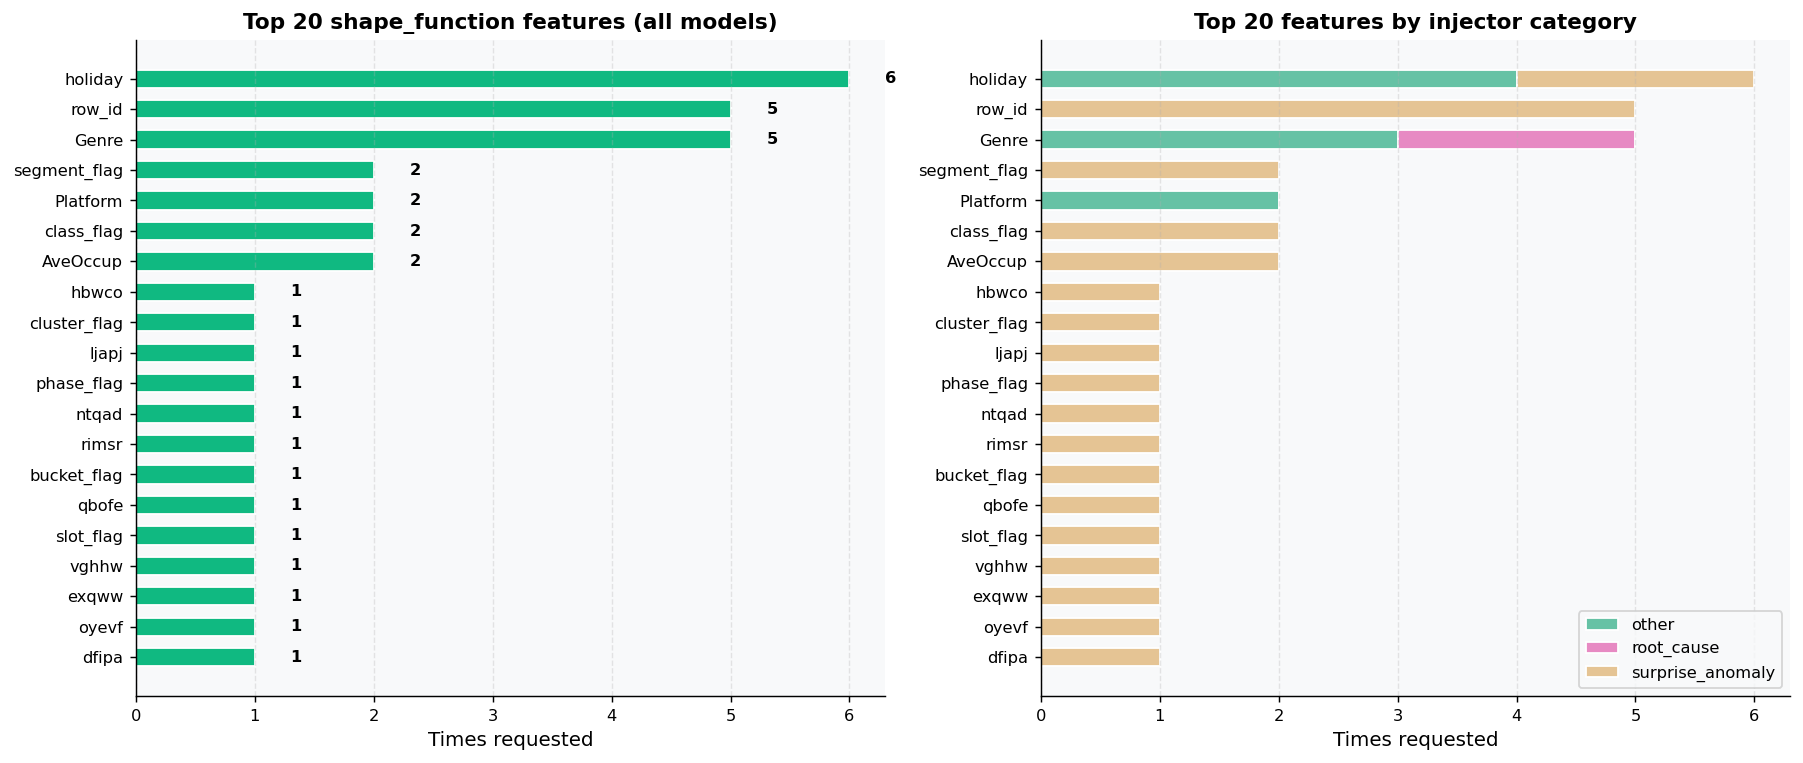

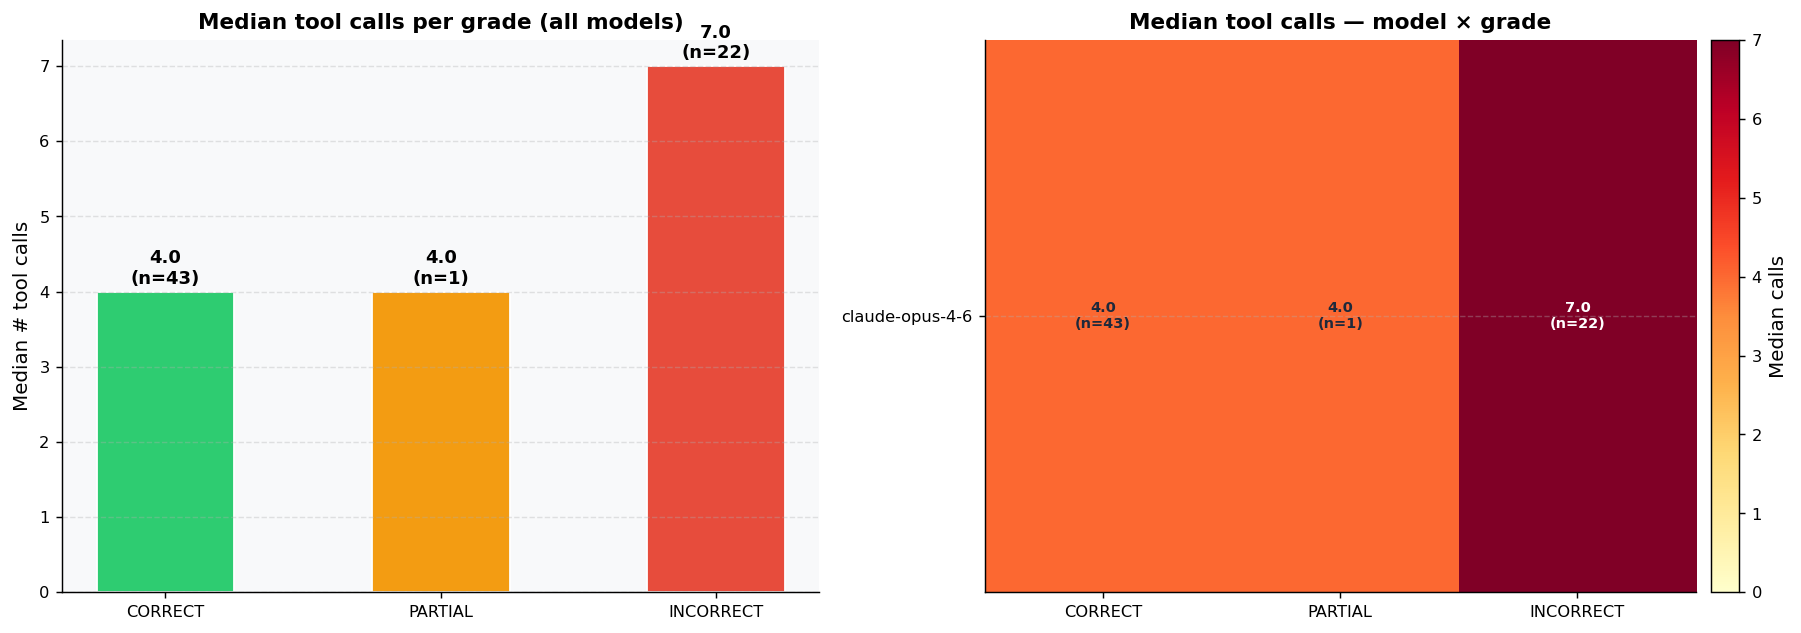

Entries where no tools were called: 0

No zero-call entries found.


In [45]:
# ── 10c: Most-requested shape_function features ───────────────────────────
if not df_sem.empty and not df_calls.empty:
    sf_calls = df_calls[df_calls["component"] == "shape_function"]
    top_n = 20

    if sf_calls.empty:
        print("No shape_function calls found.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: overall top features
        ax = axes[0]
        feat_counts = sf_calls["feature"].value_counts().head(top_n)
        bars = ax.barh(feat_counts.index[::-1], feat_counts.values[::-1],
                       color="#10b981", height=0.6, edgecolor="white")
        for bar, v in zip(bars, feat_counts.values[::-1]):
            ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                    str(v), va="center", fontsize=9, fontweight="bold")
        ax.set_xlabel("Times requested")
        ax.set_title(f"Top {top_n} shape_function features (all models)")
        ax.grid(axis="x", alpha=0.3)
        ax.grid(axis="y", alpha=0)

        # Right: feature requests broken out by template category
        ax2 = axes[1]
        top_feats = feat_counts.index.tolist()
        categories_sf = sorted(sf_calls["category"].unique())
        CAT_COLORS_SF = plt.cm.Set2(np.linspace(0, 0.8, len(categories_sf)))

        cat_feat = (
            sf_calls[sf_calls["feature"].isin(top_feats)]
            .groupby(["feature", "category"]).size()
            .unstack(fill_value=0)
            .reindex(index=top_feats)
        )
        lefts = np.zeros(len(top_feats))
        for ci, cat in enumerate(categories_sf):
            if cat not in cat_feat.columns:
                continue
            vals = cat_feat[cat].values
            ax2.barh(top_feats[::-1], vals[::-1], left=lefts[::-1],
                     color=CAT_COLORS_SF[ci], label=cat, height=0.6, edgecolor="white")
            lefts = lefts + vals

        ax2.set_xlabel("Times requested")
        ax2.set_title(f"Top {top_n} features by injector category")
        ax2.legend(fontsize=9, loc="lower right")
        ax2.grid(axis="x", alpha=0.3)
        ax2.grid(axis="y", alpha=0)

        plt.tight_layout()
        plt.show()

    # ── 10d: Tool call count vs grade ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: median n_calls per grade bucket (all models)
    ax = axes[0]
    GRADE_ORDER = ["CORRECT", "PARTIAL", "INCORRECT"]
    grade_calls = df_sem[df_sem["grade"].notna()]
    medians_gc = [grade_calls[grade_calls["grade"] == g]["n_calls"].median() for g in GRADE_ORDER]
    counts_gc_bar = [len(grade_calls[grade_calls["grade"] == g]) for g in GRADE_ORDER]
    colors = [GRADE_COLORS[g] for g in GRADE_ORDER]
    bars = ax.bar(GRADE_ORDER, medians_gc, color=colors, width=0.5, edgecolor="white")
    for bar, v, n in zip(bars, medians_gc, counts_gc_bar):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                f"{v:.1f}\n(n={n})", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel("Median # tool calls")
    ax.set_title("Median tool calls per grade (all models)")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0)

    # Right: heatmap — median n_calls by model × grade
    ax2 = axes[1]
    models_sem2 = sorted(df_sem["model"].unique())
    matrix_gc = np.full((len(models_sem2), len(GRADE_ORDER)), np.nan)
    counts_gc = np.zeros_like(matrix_gc, dtype=int)
    for i, m in enumerate(models_sem2):
        for j, g in enumerate(GRADE_ORDER):
            sub = df_sem[(df_sem["model"] == m) & (df_sem["grade"] == g)]["n_calls"]
            if len(sub):
                matrix_gc[i, j] = sub.median()
                counts_gc[i, j] = len(sub)

    im = ax2.imshow(matrix_gc, aspect="auto", cmap="YlOrRd", vmin=0)
    ax2.set_xticks(range(len(GRADE_ORDER)))
    ax2.set_xticklabels(GRADE_ORDER)
    ax2.set_yticks(range(len(models_sem2)))
    ax2.set_yticklabels(models_sem2, fontsize=9)
    for i in range(len(models_sem2)):
        for j in range(len(GRADE_ORDER)):
            v = matrix_gc[i, j]
            n = counts_gc[i, j]
            if not np.isnan(v):
                ax2.text(j, i, f"{v:.1f}\n(n={n})", ha="center", va="center",
                         fontsize=8, fontweight="bold",
                         color="white" if v > matrix_gc[~np.isnan(matrix_gc)].max() * 0.7 else "#1e293b")
    plt.colorbar(im, ax=ax2, label="Median calls", fraction=0.04, pad=0.02)
    ax2.set_title("Median tool calls — model × grade")

    plt.tight_layout()
    plt.show()

    # ── 10e: Entries with 0 tool calls ────────────────────────────────────
    zero_df = df_sem[df_sem["n_calls"] == 0][
        ["model", "dataset", "template_id", "grade", "model_answer"]
    ].copy()

    print(f"Entries where no tools were called: {len(zero_df)}")
    print()

    if len(zero_df):
        print("Breakdown by model:")
        print(zero_df["model"].value_counts().to_string())
        print()
        print("Grade distribution (zero-call entries):")
        print(zero_df["grade"].value_counts().to_string())
        print()
        corr_rate = (zero_df["grade"] == "CORRECT").mean()
        all_rate = (df_sem[df_sem["grade"].notna()]["grade"] == "CORRECT").mean()
        print(f"CORRECT rate — zero-call entries : {corr_rate:.1%}")
        print(f"CORRECT rate — all entries       : {all_rate:.1%}")
        print()

        print("Sample zero-call answers (first 5):")
        for _, row in zero_df.head(5).iterrows():
            ans = str(row["model_answer"])[:200].replace("\n", " ")
            grade_str = f"  [{row['grade']}]"
            print(f"  {row['model']} / {row['dataset']} / {row['template_id']}{grade_str}")
            print(f"    → {ans}")
            print()
    else:
        print("No zero-call entries found.")

---
## 11 — Performance Excluding 10k-Row Datasets

Since 10k-row datasets cause empty answers for csv_context (29% error rate),
this section filters them out entirely so we can compare modes on an equal footing.

Records after excluding 10k-row datasets: 80 / 114
Datasets kept: ['bike_sharing_100', 'bike_sharing_1000', 'bike_sharing_500', 'california_housing_100', 'california_housing_1000', 'california_housing_500', 'vgsales_100', 'vgsales_1000', 'vgsales_500']


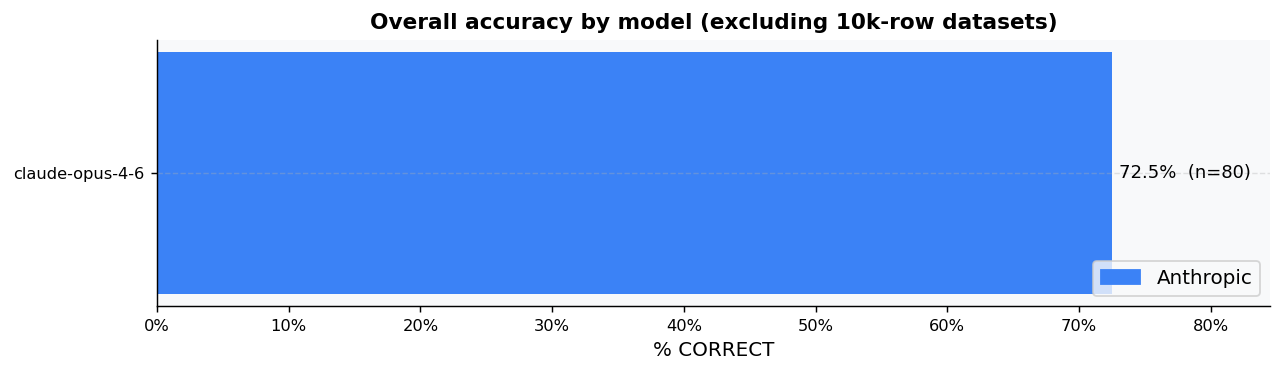

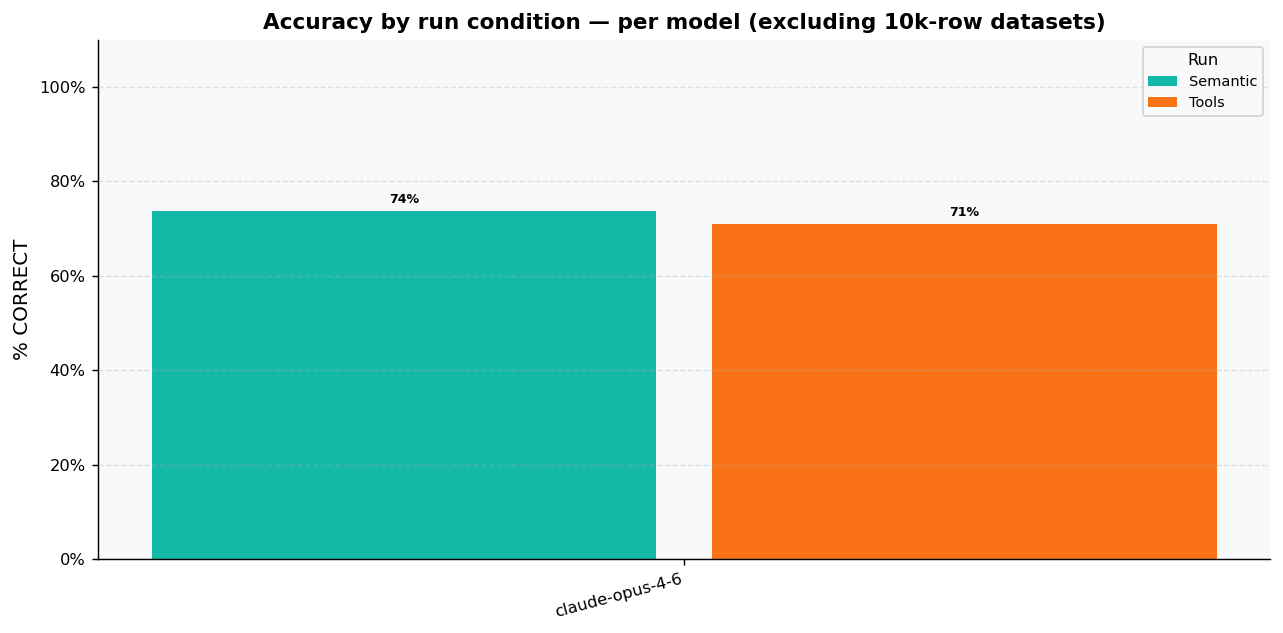

In [46]:
df_small = df_ok[df_ok["dataset_size"] < 10_000].copy()
print(f"Records after excluding 10k-row datasets: {len(df_small)} / {len(df_ok)}")
print(f"Datasets kept: {sorted(df_small['dataset'].unique())}")

# ── 11a: Accuracy by model (excluding 10k rows) ───────────────────────────
models_s = sorted(df_small["model"].unique())
acc_s = (
    df_small.groupby("model")["grade"]
    .apply(lambda g: (g == "CORRECT").mean())
    .reindex(models_s)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(3, len(models_s) * 0.6)))
colors = [PROVIDER_COLORS.get(df_small[df_small["model"] == m]["provider"].iloc[0], "#94a3b8")
          for m in acc_s.index]
ax.barh(acc_s.index, acc_s.values, color=colors)
for i, (m, v) in enumerate(acc_s.items()):
    n = len(df_small[df_small["model"] == m])
    ax.text(v + 0.005, i, f"{v:.1%}  (n={n})", va="center", fontsize=10)
ax.set_xlim(0, acc_s.max() + 0.12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xlabel("% CORRECT")
ax.set_title("Overall accuracy by model (excluding 10k-row datasets)")
present = sorted(df_small["provider"].unique())
ax.legend(handles=[Patch(color=PROVIDER_COLORS.get(p, "#94a3b8"), label=p) for p in present],
          loc="lower right")
plt.tight_layout()
plt.show()

# ── 11b: Accuracy by run condition per model (excluding 10k rows) ─────────
present_runs_s = [r for r in RUN_ORDER if r in df_small["run"].values]
n_runs = len(present_runs_s)
n_models = len(models_s)
bar_w = 0.8 / max(n_runs, 1)

fig, ax = plt.subplots(figsize=(max(10, n_models * 1.4), 5))
x = np.arange(n_models)

for ri, run in enumerate(present_runs_s):
    accs = []
    for m in models_s:
        sub = df_small[(df_small["model"] == m) & (df_small["run"] == run)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
    offset = (ri - n_runs / 2 + 0.5) * bar_w
    label = RUN_LABELS.get(run, run)
    color = RUN_COLORS.get(run, "#94a3b8")
    bars = ax.bar(x + offset, accs, bar_w * 0.9, label=label, color=color)
    for b, v in zip(bars, accs):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.0%}",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models_s, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by run condition — per model (excluding 10k-row datasets)")
ax.legend(title="Run", fontsize=8, title_fontsize=9, loc="upper right")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()